# Handle Class Imbalance — Custom Sampling (target per-kelas, multi-teknik) vs Adjusted Model

**Custom + multi-teknik.** Sama seperti *hybrid* — membandingkan **SMOTE**, **SMOTEENN** (SMOTE + Edited Nearest Neighbours), dan **SMOTETomek** (SMOTE + Tomek Links) terhadap baseline **adjusted** (class_weight balanced) pada 7 model identik — **bedanya jumlah tiap kelas BISA DIATUR** lewat `CUSTOM_TARGETS` (lihat sel Konfigurasi), dihitung **per fold**. Resampling hanya pada **fold training** (anti-bocor).

Tiap teknik dibangun via `make_custom_resampler(CUSTOM_TARGETS, class_names, over_method=..., under_method='random')`:
- bagian **over** menaikkan kelas yang target > jumlahnya (mis. B → jumlah C); `smote` mencapai target **eksak**, `smoteenn`/`smotetomek` mencapai target lalu **membersihkan batas** (jumlah akhir bisa sedikit di bawah target, dan kelas lain ikut terpangkas — ENN lebih agresif dari Tomek),
- bagian **under** (RandomUnderSampler) menurunkan kelas yang target < jumlahnya (mis. E → jumlah C) secara **eksak**.

Dataset `Dataset_TehHijau.csv`. CV memakai `StratifiedGroupKFold` dengan grup `Sampling_ID` (replika dari satu sampel tak tersebar ke train + validasi); metrik andalan **balanced accuracy** & **macro-F1**.

> ℹ️ Karena target bisa diatur ke level menengah (mis. C ≈ 1828/fold, bukan mayoritas E ≈ 3720), runtime jauh lebih ringan daripada hybrid yang meng-oversample ke level mayoritas. Edit `CUSTOM_TARGETS` / `TECHNIQUES` di sel Konfigurasi untuk coba-coba.


In [11]:
!python -m pip install -q numpy pandas scikit-learn imbalanced-learn \
    xgboost catboost matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import sys, os
import warnings
warnings.filterwarnings('ignore')

cwd = os.path.abspath(os.getcwd())
project_root = cwd.split('codes')[0] + 'codes'
sys.path.append(os.path.abspath(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [13]:
import importlib

def reload_package(package_name):
    for name in sorted([n for n in sys.modules if n.startswith(package_name)], reverse=True):
        importlib.reload(sys.modules[name])

reload_package('utils')

## 1. Konfigurasi

In [14]:
from utils.imbalance_eval import (
    make_custom_resampler, evaluate_cv, resample_for_viz,
    make_resample_pipeline, BEST_PARAMS, MODEL_ORDER)

dataset_path = os.path.join(project_root, 'dataset', 'Dataset_TehHijau.csv')

feature_cols = [
    'MQ3', 'TGS822', 'TGS2602', 'MQ5', 'MQ138', 'TGS2620',
    'TGS813', 'TGS2600', 'TGS2611', 'TGS2603', 'Humidity', 'Celsius',
]
target_col = 'Kategori'
group_col  = 'Sampling_ID'   # grup CV (StratifiedGroupKFold) — replika 1 sampel tak bocor
CV_STRATEGY = 'stratified_group'   # StratifiedGroupKFold by Sampling_ID

# Target sampling kustom per-kelas — EDIT untuk coba-coba.
#   nilai = int (jumlah absolut) ATAU nama kelas lain (samakan jumlahnya).
#   kelas yang TIDAK disebut = tidak diubah. Default: B & E -> jumlah C.
CUSTOM_TARGETS = {'B': 'C', 'E': 'C'}

# Teknik yang dibandingkan -> over_method di make_custom_resampler. Semua memakai
# CUSTOM_TARGETS + RUS (UNDER_METHOD) untuk undersampling. Komentari yang tak perlu.
TECHNIQUES = {
    'SMOTE':      'smote',
    'SMOTEENN':   'smoteenn',
    'SMOTETomek': 'smotetomek',
}
UNDER_METHOD = 'random'   # 'random' (RUS, target eksak) | 'tomek' (cleaning, tak bertarget)
RESAMPLERS = None         # dibangun setelah class_names tersedia (sel di bawah)
STRATEGY = 'custom_v2'   # suffix _v2 agar output tak menimpa custom_sampling.ipynb

XGB_DEVICE   = 'cuda'   # ganti 'cpu' kalau tak ada GPU
CAT_TASK_TYPE = 'GPU'   # ganti 'CPU' kalau tak ada GPU

MODELS = list(MODEL_ORDER)
print('Models:', MODELS)
print('Teknik:', list(TECHNIQUES.keys()), '| CUSTOM_TARGETS =', CUSTOM_TARGETS)

OUT_DIR = os.path.join(cwd, 'results', STRATEGY)
os.makedirs(OUT_DIR, exist_ok=True)
print('Output:', OUT_DIR)


Models: ['SVC Linear', 'SVC Sigmoid', 'SVC Poly', 'SVC RBF', 'XGBoost GBTree', 'XGBoost Dart', 'CatBoost']
Teknik: ['SMOTE', 'SMOTEENN', 'SMOTETomek'] | CUSTOM_TARGETS = {'B': 'C', 'E': 'C'}
Output: c:\`Bioinformatics\quantum-gesang\codes\notebooks\handle_imbalance\results\custom_v2


## 2. Muat Data & Distribusi Kelas

In [15]:
data = pd.read_csv(dataset_path)
print('shape:', data.shape)
data[target_col].value_counts().sort_index()

shape: (10409, 130)


Kategori
A     927
B     229
C    2287
D    2317
E    4649
Name: count, dtype: int64

In [16]:
from sklearn.preprocessing import LabelEncoder

X = data[feature_cols]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data[target_col])
groups = data[group_col].values
labels = np.unique(y)
class_names = list(label_encoder.classes_)
print('X:', X.shape, '| classes:', class_names, '| n grup:', len(np.unique(groups)))

X: (10409, 12) | classes: ['A', 'B', 'C', 'D', 'E'] | n grup: 274


In [17]:
# Bangun satu resampler per teknik; semuanya menghormati CUSTOM_TARGETS (per fold).
# under_method=UNDER_METHOD menurunkan kelas yang target<jumlah (mis. E -> C) eksak;
# over_method menaikkan kelas yang target>jumlah (mis. B -> C).
RESAMPLERS = {
    name: make_custom_resampler(CUSTOM_TARGETS, class_names,
                                over_method=om, under_method=UNDER_METHOD)
    for name, om in TECHNIQUES.items()
}
print('Resampler siap:', list(RESAMPLERS.keys()))
print('  CUSTOM_TARGETS =', CUSTOM_TARGETS, '| under =', UNDER_METHOD)


Resampler siap: ['SMOTE', 'SMOTEENN', 'SMOTETomek']
  CUSTOM_TARGETS = {'B': 'C', 'E': 'C'} | under = random


## 3. PCA — jumlah komponen optimal (95% varians)

In [18]:
from sklearn.decomposition import PCA

_pca = PCA(n_components=X.shape[1]).fit(X)
cumvar = np.cumsum(_pca.explained_variance_ratio_)
n_optimal = int(np.argmax(cumvar >= 0.95) + 1)
print('n_optimal =', n_optimal)

n_optimal = 4


## 4. Komposisi Dataset — Sebelum vs Sesudah (tiap teknik)

Jumlah baris per kelas pada 1 fold training, untuk tiap teknik (semua memakai `CUSTOM_TARGETS`). Histogram tidak terpengaruh PCA; scatter PC1–PC2 menampilkan sebaran fitur. Perhatikan: `smote` mencapai target eksak, sedang `smoteenn`/`smotetomek` membersihkan batas sehingga jumlah akhir bisa sedikit berbeda dari target.


Komposisi kelas (1 fold training):
   Sebelum  SMOTE  SMOTEENN  SMOTETomek
A      733    733       643         716
B      181   1828      1828        1828
C     1828   1828      1761        1820
D     1854   1854      1768        1840
E     3720   1828      1783        1821


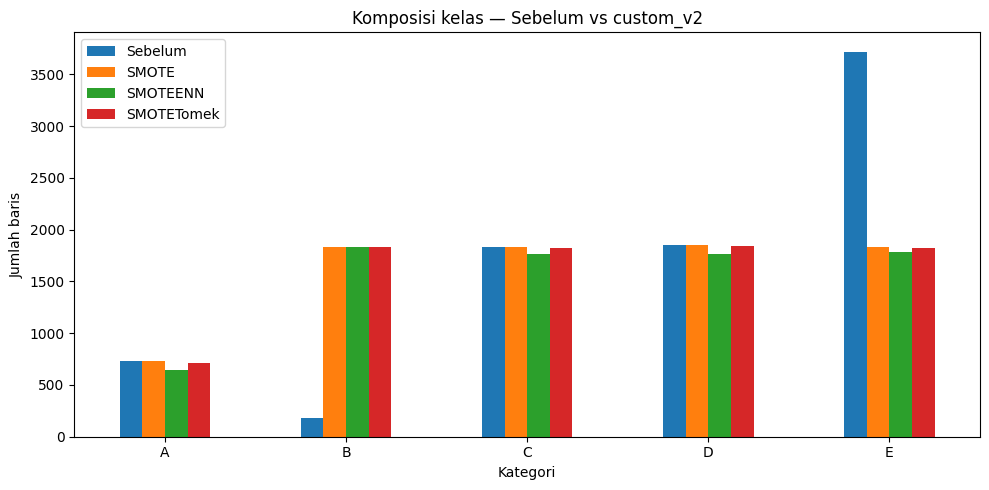

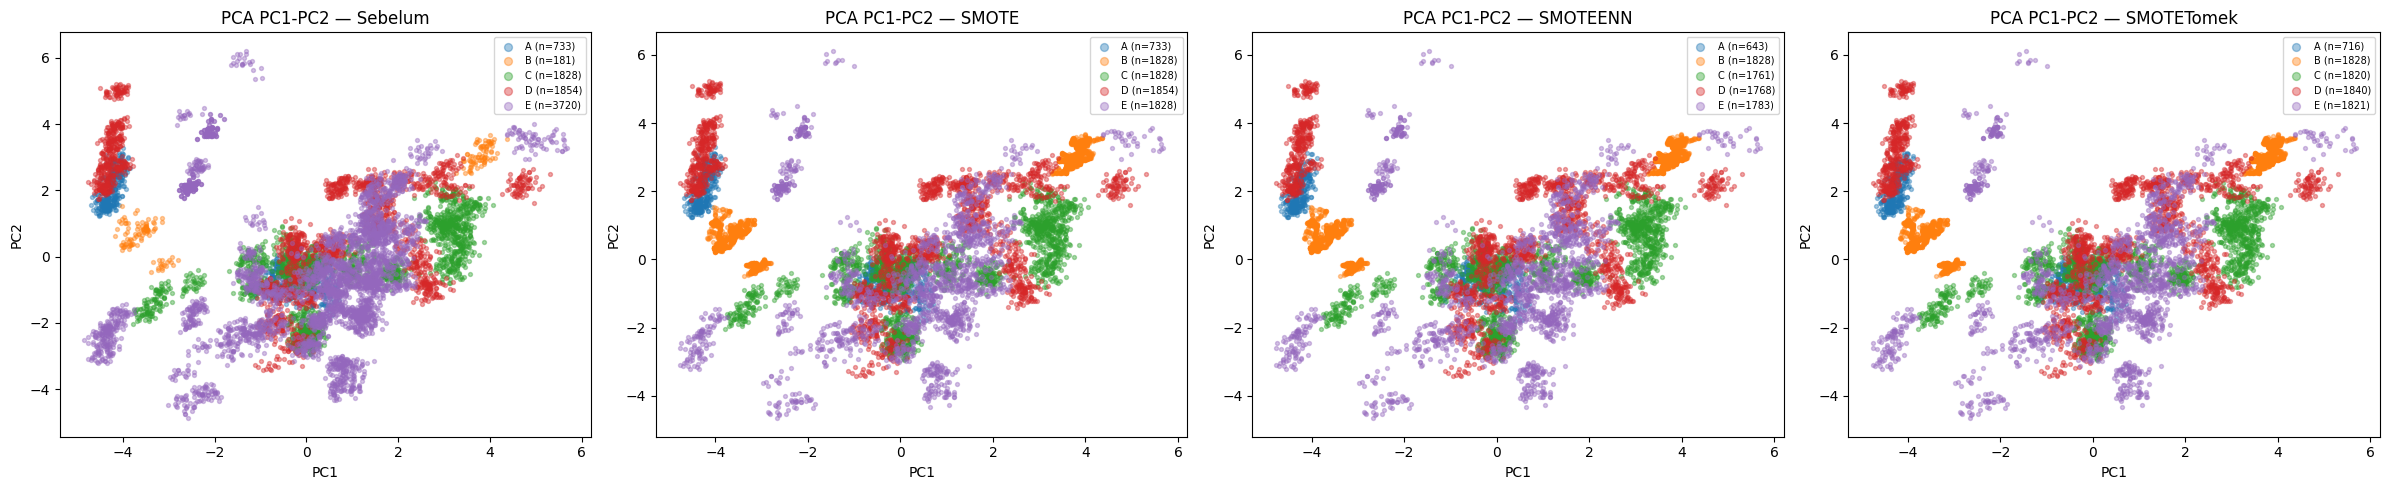

In [19]:
from collections import Counter

comp = pd.DataFrame(index=class_names)
before_xy = None
scatters = []
for tech, R in RESAMPLERS.items():
    v = resample_for_viz(X, y, groups, R, n_optimal, fold_index=0, cv_strategy=CV_STRATEGY)
    if before_xy is None:
        before_xy = (v['X_before'], v['y_before'])
        comp['Sebelum'] = [Counter(v['y_before']).get(i, 0) for i in labels]
    comp[tech] = [Counter(v['y_after']).get(i, 0) for i in labels]
    scatters.append((tech, v['X_after'], v['y_after']))
print('Komposisi kelas (1 fold training):'); print(comp)
comp.to_csv(os.path.join(OUT_DIR, f'{STRATEGY}_composition.csv'))

ax = comp.plot(kind='bar', figsize=(10, 5))
ax.set_title(f'Komposisi kelas — Sebelum vs {STRATEGY}')
ax.set_xlabel('Kategori'); ax.set_ylabel('Jumlah baris'); ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'{STRATEGY}_composition_bar.png'), dpi=130, bbox_inches='tight')
plt.show()

cmap = plt.cm.tab10
panels = [('Sebelum', before_xy[0], before_xy[1])] + [(t, Xa, ya) for (t, Xa, ya) in scatters]
ncols = len(panels)
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))
axes = np.atleast_1d(axes)
for ax, (ttl, Xp, yp) in zip(axes, panels):
    for i, cn in enumerate(class_names):
        m = yp == labels[i]
        ax.scatter(Xp[m, 0], Xp[m, 1], s=8, alpha=0.4, color=cmap(i), label=f'{cn} (n={int(m.sum())})')
    ax.set_title(f'PCA PC1-PC2 — {ttl}'); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=7, markerscale=2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'{STRATEGY}_composition_scatter.png'), dpi=130, bbox_inches='tight')
plt.show()

## 5. Evaluasi: Adjusted vs tiap teknik hybrid

Tiap model dijalankan untuk **adjusted** (balanced, tanpa resampling) lalu **tiap teknik** (resampling di fold training, classifier tanpa bobot).

In [20]:
import time
from pathlib import Path
from datetime import datetime

log_path = Path(OUT_DIR) / f'{STRATEGY}_run.log'
log_path.write_text('', encoding='utf-8')

def log(msg=''):
    print(msg)
    with open(log_path, 'a', encoding='utf-8') as f:
        f.write(str(msg) + '\n')

log(f'Started: {datetime.now().isoformat(timespec="seconds")} | strategy={STRATEGY}')

common = dict(n_optimal=n_optimal, labels=labels, cv_strategy=CV_STRATEGY,
              xgb_device=XGB_DEVICE, cat_task_type=CAT_TASK_TYPE, log=log)
STRATEGIES = ['adjusted'] + list(RESAMPLERS.keys())

all_results = []
for name in MODELS:
    params = BEST_PARAMS[name]
    for strat in STRATEGIES:
        log(f'\n=== {name} | {strat} ===')
        try:
            if strat == 'adjusted':
                r = evaluate_cv(X, y, groups, name, params, mode='adjusted', **common)
            else:
                r = evaluate_cv(X, y, groups, name, params, mode='resample',
                                resampler=RESAMPLERS[strat], **common)
            r['strategy'] = strat
            all_results.append(r)
        except Exception as e:
            log(f'  FAILED [{name} | {strat}] -> {type(e).__name__}: {e}')
log(f'\nDone. {len(all_results)} (model x strategi).')

Started: 2026-06-06T18:19:37 | strategy=custom_v2

=== SVC Linear | adjusted ===
    F1 -> Acc=0.3865 | BalAcc=0.5050 | MacroF1=0.3568 | AUROC=0.6914 | PRAUC=0.5121
    F2 -> Acc=0.2642 | BalAcc=0.2482 | MacroF1=0.2159 | AUROC=0.5719 | PRAUC=0.3779
    F3 -> Acc=0.3374 | BalAcc=0.4648 | MacroF1=0.3268 | AUROC=0.6806 | PRAUC=0.4564
    F4 -> Acc=0.3337 | BalAcc=0.3535 | MacroF1=0.2800 | AUROC=0.7416 | PRAUC=0.5326
    F5 -> Acc=0.3088 | BalAcc=0.4169 | MacroF1=0.2888 | AUROC=0.6208 | PRAUC=0.4193
  OK [SVC Linear | adjusted] BalAcc=0.3977 MacroF1=0.2937 AUROC=0.6613 MCC=0.1768 (72.0s)

=== SVC Linear | SMOTE ===
    F1 -> Acc=0.4338 | BalAcc=0.4781 | MacroF1=0.3804 | AUROC=0.6884 | PRAUC=0.5284
    F2 -> Acc=0.3821 | BalAcc=0.3796 | MacroF1=0.3060 | AUROC=0.5764 | PRAUC=0.4145
    F3 -> Acc=0.4364 | BalAcc=0.5477 | MacroF1=0.4008 | AUROC=0.6914 | PRAUC=0.4942
    F4 -> Acc=0.3365 | BalAcc=0.3344 | MacroF1=0.2518 | AUROC=0.6856 | PRAUC=0.4804
    F5 -> Acc=0.4138 | BalAcc=0.4874 | MacroF

## 6. Tabel Perbandingan

In [21]:
metric_cols = ['balanced_accuracy', 'macro_f1', 'accuracy', 'weighted_f1',
               'precision', 'recall', 'roc_auc', 'pr_auc', 'mcc', 'execution_time']
# Metrik yang dihitung per fold -> punya std (mcc & execution_time tidak).
std_metrics = [m for m in metric_cols if any(f'{m}_std' in r for r in all_results)]

# DataFrame numerik lengkap: mean + std tiap metrik (untuk CSV & komputasi lain).
rows = []
for r in all_results:
    row = {'Model': r['model'], 'Strategy': r['strategy']}
    for m in metric_cols:
        row[m] = r[m]
        if f'{m}_std' in r:
            row[f'{m}_std'] = r[f'{m}_std']
    rows.append(row)
res_df = pd.DataFrame(rows)
res_df.to_csv(os.path.join(OUT_DIR, f'{STRATEGY}_metrics_long.csv'), index=False)

# Tabel tampil: tiap metrik sebagai 'mean +/- std' (yang punya std).
disp = pd.DataFrame({'Model': res_df['Model'], 'Strategy': res_df['Strategy']})
for m in metric_cols:
    if m in std_metrics:
        disp[m] = [f'{mu:.4f} ± {sd:.4f}'
                   for mu, sd in zip(res_df[m], res_df[f'{m}_std'])]
    else:
        disp[m] = res_df[m].map(lambda v: f'{v:.4f}')
disp

,Model,Strategy,balanced_accuracy,macro_f1,accuracy,weighted_f1,precision,recall,roc_auc,pr_auc,mcc,execution_time
0,SVC Linear,adjusted,0.3977 ± 0.0902,0.2937 ± 0.0476,0.3261 ± 0.0399,0.3500 ± 0.0373,0.5370 ± 0.0322,0.3261 ± 0.0399,0.6613 ± 0.0589,0.4597 ± 0.0573,0.1768,71.9531
1,SVC Linear,SMOTE,0.4454 ± 0.0774,0.3295 ± 0.0542,0.4006 ± 0.0374,0.3984 ± 0.0307,0.5051 ± 0.0578,0.4006 ± 0.0374,0.6552 ± 0.0447,0.4696 ± 0.0418,0.2349,39.9622
2,SVC Linear,SMOTEENN,0.4517 ± 0.0695,0.3297 ± 0.0499,0.4007 ± 0.0359,0.3986 ± 0.0302,0.5056 ± 0.0559,0.4007 ± 0.0359,0.6542 ± 0.0464,0.4700 ± 0.0441,0.2357,37.0160
3,SVC Linear,SMOTETomek,0.4452 ± 0.0767,0.3286 ± 0.0534,0.4005 ± 0.0370,0.3983 ± 0.0307,0.5058 ± 0.0585,0.4005 ± 0.0370,0.6555 ± 0.0452,0.4701 ± 0.0424,0.2351,39.0376
4,SVC Sigmoid,adjusted,0.2147 ± 0.0654,0.1488 ± 0.0487,0.1565 ± 0.0562,0.1778 ± 0.0719,0.3063 ± 0.0826,0.1565 ± 0.0562,0.6496 ± 0.0668,0.4272 ± 0.0701,0.0128,98.6755
5,SVC Sigmoid,SMOTE,0.2098 ± 0.0616,0.1590 ± 0.0324,0.1869 ± 0.0409,0.2175 ± 0.0490,0.3043 ± 0.0605,0.1869 ± 0.0409,0.5930 ± 0.0754,0.3834 ± 0.0575,0.0108,70.5212
6,SVC Sigmoid,SMOTEENN,0.2091 ± 0.0570,0.1573 ± 0.0266,0.1902 ± 0.0343,0.2208 ± 0.0427,0.3063 ± 0.0534,0.1902 ± 0.0343,0.5899 ± 0.0689,0.3802 ± 0.0574,0.0132,66.3405
7,SVC Sigmoid,SMOTETomek,0.2113 ± 0.0591,0.1601 ± 0.0299,0.1887 ± 0.0386,0.2196 ± 0.0471,0.3063 ± 0.0595,0.1887 ± 0.0386,0.5929 ± 0.0758,0.3834 ± 0.0579,0.0124,71.7617
8,SVC Poly,adjusted,0.4775 ± 0.0593,0.3514 ± 0.0565,0.3892 ± 0.0518,0.3638 ± 0.0567,0.5814 ± 0.1251,0.3892 ± 0.0518,0.7299 ± 0.0394,0.5345 ± 0.0531,0.2500,73.1019
9,SVC Poly,SMOTE,0.4344 ± 0.0278,0.2809 ± 0.0171,0.3809 ± 0.0273,0.3570 ± 0.0336,0.5855 ± 0.0799,0.3809 ± 0.0273,0.7076 ± 0.0353,0.5148 ± 0.0368,0.2431,44.4590


In [22]:
# -- Rincian nilai per fold tiap metrik (mean +/- std dihitung dari sini) --
# Mengambil list *_folds dari evaluate_cv: satu baris per (model, strategi, fold).
fold_rows = []
for r in all_results:
    n_folds = len(r.get('macro_f1_folds', []))
    for k in range(n_folds):
        fr = {'Model': r['model'], 'Strategy': r['strategy'], 'fold': k + 1}
        for m in std_metrics:
            fr[m] = r[f'{m}_folds'][k]
        fold_rows.append(fr)
folds_df = pd.DataFrame(fold_rows)
folds_df.to_csv(os.path.join(OUT_DIR, f'{STRATEGY}_metrics_per_fold.csv'), index=False)
print(f'Nilai per fold disimpan -> {STRATEGY}_metrics_per_fold.csv '
      f'({len(folds_df)} baris = model x strategi x fold)')
folds_df.style.format({m: '{:.4f}' for m in std_metrics})

Nilai per fold disimpan -> custom_v2_metrics_per_fold.csv (140 baris = model x strategi x fold)


,Model,Strategy,fold,balanced_accuracy,macro_f1,accuracy,weighted_f1,precision,recall,roc_auc,pr_auc
0,SVC Linear,adjusted,1,0.5050,0.3568,0.3865,0.3889,0.5979,0.3865,0.6914,0.5121
1,SVC Linear,adjusted,2,0.2482,0.2159,0.2642,0.2803,0.5246,0.2642,0.5719,0.3779
2,SVC Linear,adjusted,3,0.4648,0.3268,0.3374,0.3670,0.5396,0.3374,0.6806,0.4564
3,SVC Linear,adjusted,4,0.3535,0.2800,0.3337,0.3670,0.5099,0.3337,0.7416,0.5326
4,SVC Linear,adjusted,5,0.4169,0.2888,0.3088,0.3468,0.5128,0.3088,0.6208,0.4193
5,SVC Linear,SMOTE,1,0.4781,0.3804,0.4338,0.4386,0.5709,0.4338,0.6884,0.5284
6,SVC Linear,SMOTE,2,0.3796,0.3060,0.3821,0.3655,0.4247,0.3821,0.5764,0.4145
7,SVC Linear,SMOTE,3,0.5477,0.4008,0.4364,0.4309,0.5681,0.4364,0.6914,0.4942
8,SVC Linear,SMOTE,4,0.3344,0.2518,0.3365,0.3694,0.5003,0.3365,0.6856,0.4804
9,SVC Linear,SMOTE,5,0.4874,0.3085,0.4138,0.3876,0.4615,0.4138,0.6344,0.4305


In [23]:
# Strategi terbaik per model (balanced_accuracy)
best = (res_df.sort_values('balanced_accuracy', ascending=False)
        .groupby('Model', sort=False).first()[['Strategy', 'balanced_accuracy', 'macro_f1', 'roc_auc', 'mcc']])
best = best.reindex([m for m in MODELS if m in best.index])
best.to_csv(os.path.join(OUT_DIR, f'{STRATEGY}_best_per_model.csv'))
log('Strategi terbaik per model (balanced_accuracy):')
for m, row in best.iterrows():
    log(f"  {m:<16s} -> {row['Strategy']:<12s} BalAcc={row['balanced_accuracy']:.4f} MacroF1={row['macro_f1']:.4f}")
best

Strategi terbaik per model (balanced_accuracy):
  SVC Linear       -> SMOTEENN     BalAcc=0.4517 MacroF1=0.3297
  SVC Sigmoid      -> adjusted     BalAcc=0.2147 MacroF1=0.1488
  SVC Poly         -> adjusted     BalAcc=0.4775 MacroF1=0.3514
  SVC RBF          -> adjusted     BalAcc=0.6566 MacroF1=0.5926
  XGBoost GBTree   -> adjusted     BalAcc=0.5736 MacroF1=0.4655
  XGBoost Dart     -> SMOTETomek   BalAcc=0.5170 MacroF1=0.4042
  CatBoost         -> adjusted     BalAcc=0.5804 MacroF1=0.4652


,Strategy,balanced_accuracy,macro_f1,roc_auc,mcc
Model,,,,,
SVC Linear,SMOTEENN,0.4517,0.3297,0.6542,0.2357
SVC Sigmoid,adjusted,0.2147,0.1488,0.6496,0.0128
SVC Poly,adjusted,0.4775,0.3514,0.7299,0.2500
SVC RBF,adjusted,0.6566,0.5926,0.8681,0.4777
XGBoost GBTree,adjusted,0.5736,0.4655,0.7945,0.3499
XGBoost Dart,SMOTETomek,0.5170,0.4042,0.7895,0.3478
CatBoost,adjusted,0.5804,0.4652,0.7976,0.3574


## 7. Visual: Balanced Accuracy & Macro-F1 per strategi

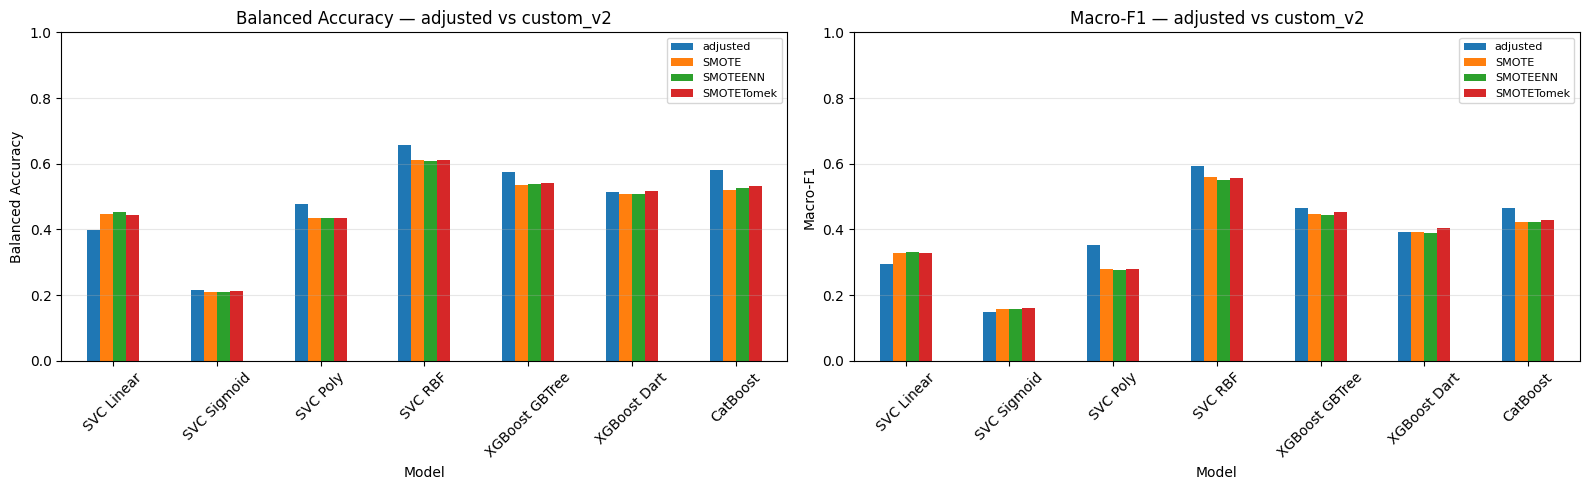

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, metric, title in zip(axes, ['balanced_accuracy', 'macro_f1'],
                             ['Balanced Accuracy', 'Macro-F1']):
    sub = res_df.pivot(index='Model', columns='Strategy', values=metric)
    sub = sub.reindex(index=[m for m in MODELS if m in sub.index],
                      columns=[s for s in STRATEGIES if s in sub.columns])
    sub.plot(kind='bar', ax=ax)
    ax.set_title(f'{title} — adjusted vs {STRATEGY}'); ax.set_ylabel(title)
    ax.set_ylim(0, 1.0); ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f'{STRATEGY}_bar_compare.png'), dpi=130, bbox_inches='tight')
plt.show()

## 8. Confusion Matrix Out-of-Fold

Kolom = strategi (adjusted + tiap teknik); baris = model.

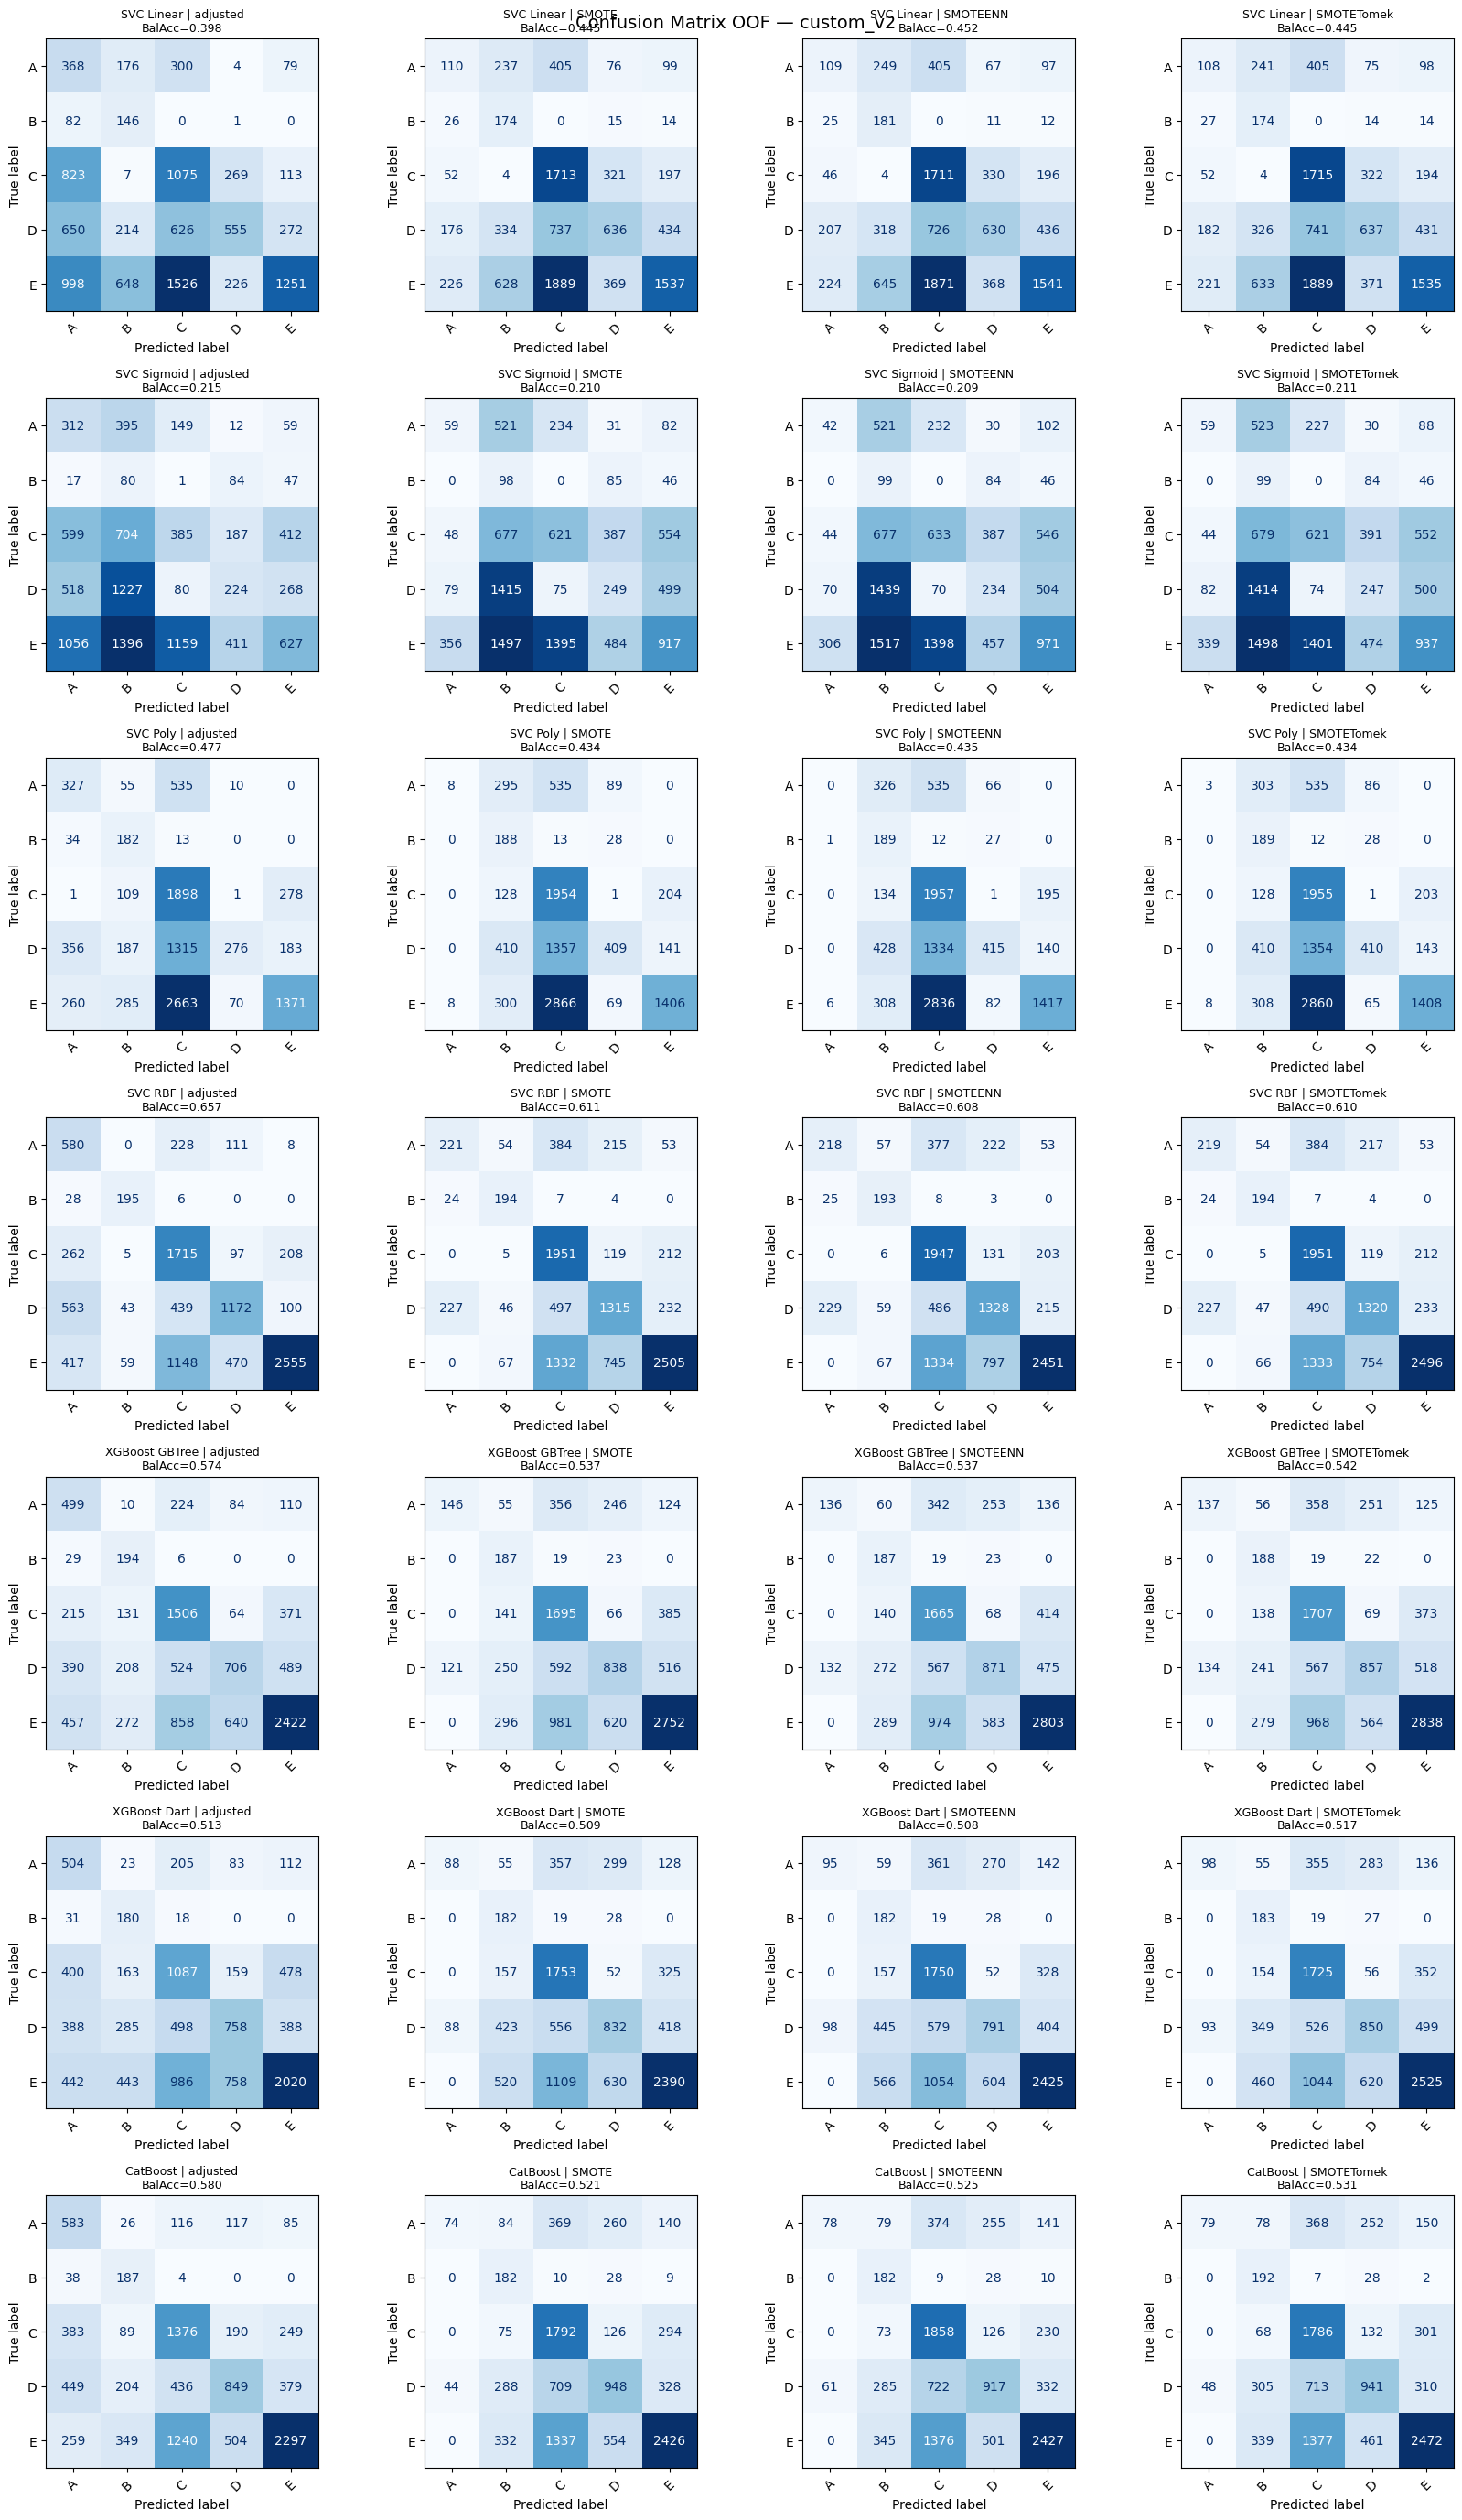

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

by_model = {}
for r in all_results:
    by_model.setdefault(r['model'], {})[r['strategy']] = r
ordered = [m for m in MODELS if m in by_model]

ncols = len(STRATEGIES); nrows = len(ordered)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4 * nrows))
axes = np.atleast_2d(axes)
for i, name in enumerate(ordered):
    for j, strat in enumerate(STRATEGIES):
        ax = axes[i, j]; r = by_model[name].get(strat)
        if r is None:
            ax.axis('off'); continue
        cm = confusion_matrix(r['y_true'], r['y_pred'], labels=labels)
        ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
            ax=ax, cmap='Blues', colorbar=False, values_format='d')
        ax.set_title(f"{name} | {strat}\nBalAcc={r['balanced_accuracy']:.3f}", fontsize=9)
        ax.tick_params(axis='x', rotation=45)
fig.suptitle(f'Confusion Matrix OOF — {STRATEGY}', fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f'{STRATEGY}_confusion_matrices.png'), dpi=120, bbox_inches='tight')
plt.show()

In [26]:
for name in ordered:
    for strat in STRATEGIES:
        r = by_model[name].get(strat)
        if r is None: continue
        log('=' * 64); log(f'{name} | {strat}')
        log(classification_report(r['y_true'], r['y_pred'], labels=labels,
                                  target_names=class_names, zero_division=0))

SVC Linear | adjusted
              precision    recall  f1-score   support

           A       0.13      0.40      0.19       927
           B       0.12      0.64      0.21       229
           C       0.30      0.47      0.37      2287
           D       0.53      0.24      0.33      2317
           E       0.73      0.27      0.39      4649

    accuracy                           0.33     10409
   macro avg       0.36      0.40      0.30     10409
weighted avg       0.52      0.33      0.35     10409

SVC Linear | SMOTE
              precision    recall  f1-score   support

           A       0.19      0.12      0.15       927
           B       0.13      0.76      0.22       229
           C       0.36      0.75      0.49      2287
           D       0.45      0.27      0.34      2317
           E       0.67      0.33      0.44      4649

    accuracy                           0.40     10409
   macro avg       0.36      0.45      0.33     10409
weighted avg       0.50      0.40   

## 9. Learning Curve — cek Overfit / Underfit (tiap teknik)

Grid: baris = model, kolom = teknik. Mode resample (classifier tanpa balanced). `probability=True` dipakai karena `scoring='neg_log_loss'` butuh `predict_proba` — tanpa ini SVC tak punya `predict_proba` sehingga skornya NaN dan kurva SVC kosong.

In [27]:
from sklearn.model_selection import learning_curve, StratifiedGroupKFold

LC_TRAIN_SIZES = np.linspace(0.2, 1.0, 5)
LC_CV = 5; LC_SCORING = 'neg_log_loss'; LC_STATE = 42
techs = list(RESAMPLERS.keys())
groups_arr = np.asarray(groups)

lc = {}
for name in MODELS:
    for tech in techs:
        log(f'  > LC: {name} | {tech} ...')
        try:
            pipe = make_resample_pipeline(name, BEST_PARAMS[name], RESAMPLERS[tech],
                                          n_optimal, xgb_device=XGB_DEVICE, cat_task_type=CAT_TASK_TYPE, probability=True)
            ts, tr, va = learning_curve(
                pipe, X, y, groups=groups_arr, train_sizes=LC_TRAIN_SIZES,
                cv=StratifiedGroupKFold(LC_CV, shuffle=True, random_state=LC_STATE),
                scoring=LC_SCORING, n_jobs=1, shuffle=True, random_state=LC_STATE)
            lc[(name, tech)] = (ts, tr.mean(1), tr.std(1), va.mean(1), va.std(1))
        except Exception as e:
            log(f'    FAILED [{name}|{tech}] -> {type(e).__name__}: {e}')
log(f'LC selesai: {len(lc)} kurva.')

  > LC: SVC Linear | SMOTE ...
  > LC: SVC Linear | SMOTEENN ...
  > LC: SVC Linear | SMOTETomek ...
  > LC: SVC Sigmoid | SMOTE ...
  > LC: SVC Sigmoid | SMOTEENN ...
  > LC: SVC Sigmoid | SMOTETomek ...
  > LC: SVC Poly | SMOTE ...
  > LC: SVC Poly | SMOTEENN ...
  > LC: SVC Poly | SMOTETomek ...
  > LC: SVC RBF | SMOTE ...
  > LC: SVC RBF | SMOTEENN ...
  > LC: SVC RBF | SMOTETomek ...
  > LC: XGBoost GBTree | SMOTE ...
  > LC: XGBoost GBTree | SMOTEENN ...
  > LC: XGBoost GBTree | SMOTETomek ...
  > LC: XGBoost Dart | SMOTE ...
  > LC: XGBoost Dart | SMOTEENN ...
  > LC: XGBoost Dart | SMOTETomek ...
  > LC: CatBoost | SMOTE ...
  > LC: CatBoost | SMOTEENN ...
  > LC: CatBoost | SMOTETomek ...
LC selesai: 21 kurva.


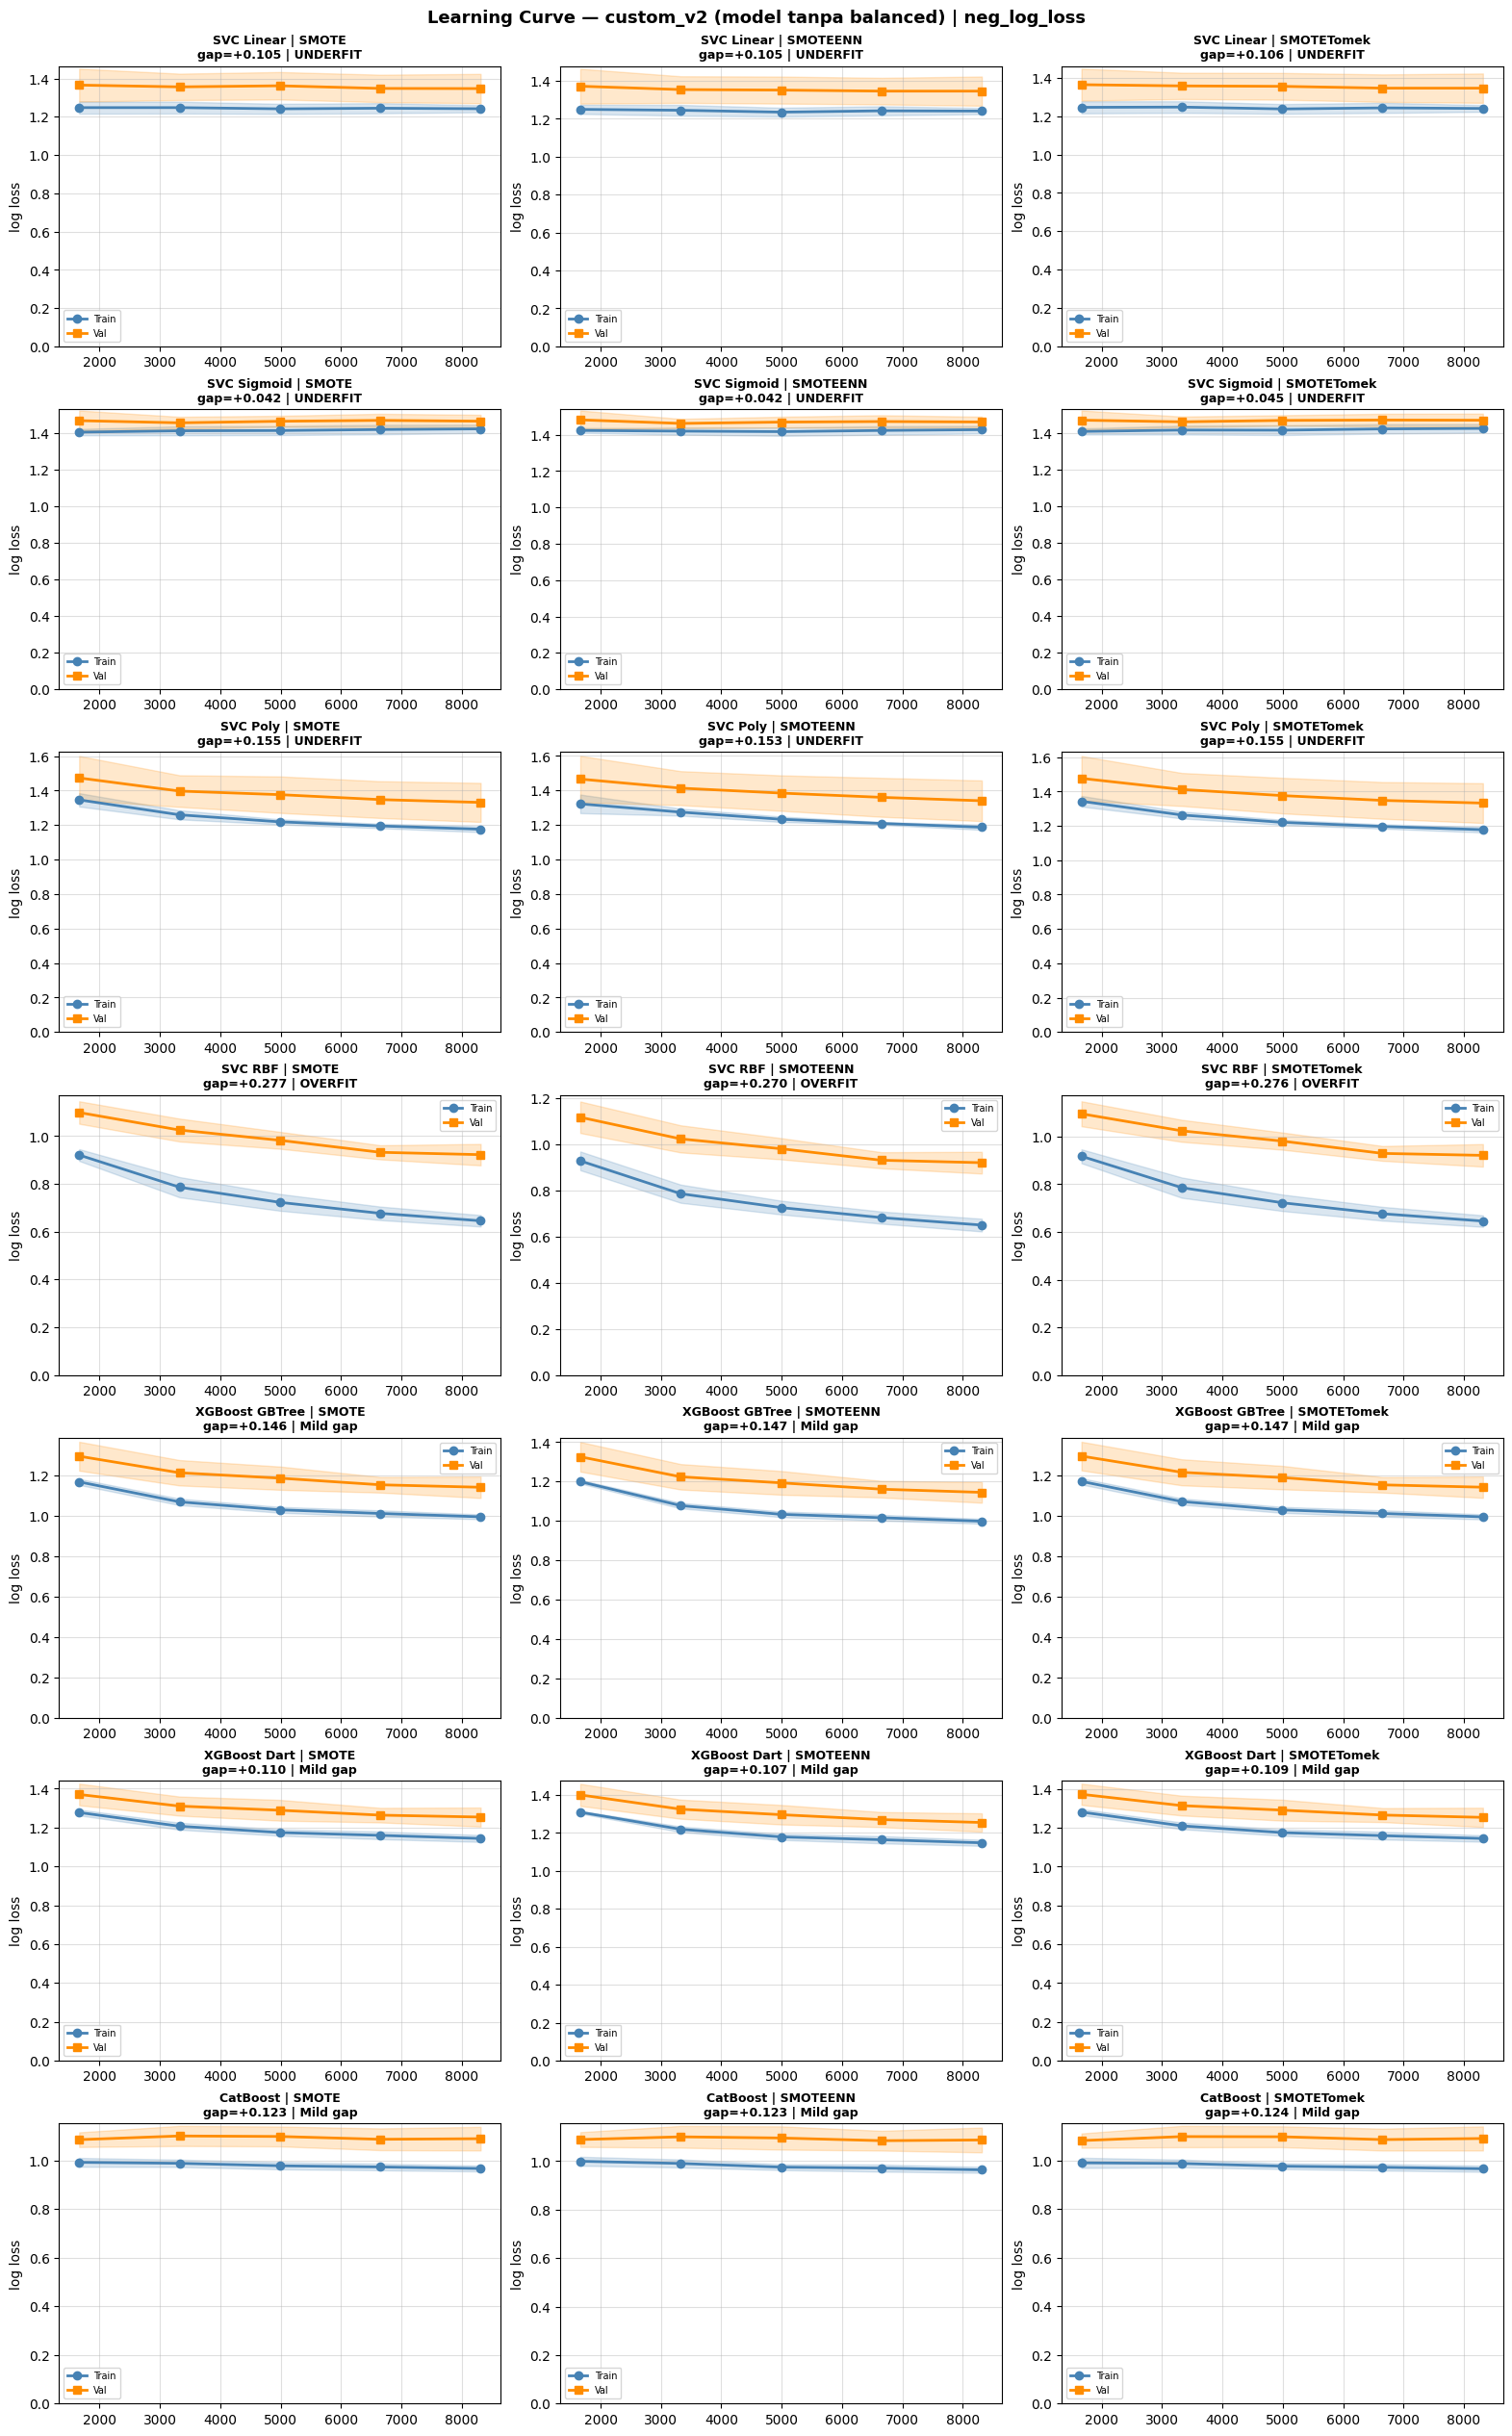

In [28]:
LC_BASELINE = float(np.log(len(np.unique(y))))   # log loss tebakan-acak (ambang verdict)
nrows = len(MODELS); ncols = len(techs)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.6 * nrows), constrained_layout=True)
axes = np.atleast_2d(axes)
for i, name in enumerate(MODELS):
    for j, tech in enumerate(techs):
        ax = axes[i, j]
        if (name, tech) not in lc:
            ax.axis('off'); continue
        ts, trm, trs, vam, vas = lc[(name, tech)]
        trm, vam = -trm, -vam   # neg_log_loss → log loss (positif; makin kecil makin baik)
        ax.plot(ts, trm, 'o-', color='steelblue', lw=2, label='Train')
        ax.fill_between(ts, trm - trs, trm + trs, alpha=0.2, color='steelblue')
        ax.plot(ts, vam, 's-', color='darkorange', lw=2, label='Val')
        ax.fill_between(ts, vam - vas, vam + vas, alpha=0.2, color='darkorange')
        gap = vam[-1] - trm[-1]   # val_loss − train_loss (>0 → overfit)
        v = ('OVERFIT' if gap > 0.15 * LC_BASELINE else 'UNDERFIT' if vam[-1] > 0.80 * LC_BASELINE
             else 'Well-fit' if gap < 0.05 * LC_BASELINE and vam[-1] < 0.40 * LC_BASELINE else 'Mild gap')
        ax.set_title(f'{name} | {tech}\ngap={gap:+.3f} | {v}', fontsize=9, fontweight='bold')
        ax.set_ylim(bottom=0); ax.set_ylabel('log loss'); ax.grid(True, alpha=0.4); ax.legend(fontsize=7)
fig.suptitle(f'Learning Curve — {STRATEGY} (model tanpa balanced) | {LC_SCORING}',
             fontsize=13, fontweight='bold')
fig.savefig(os.path.join(OUT_DIR, f'{STRATEGY}_learning_curve.png'), dpi=110, bbox_inches='tight')
plt.show()

## 10. Kurva Seluruh Metrik Evaluasi (Train vs Val)

Learning curve untuk **semua** metrik sekaligus: **accuracy, precision, recall, f1 (macro)** dan **loss function (log loss)** terhadap ukuran data latih. Tiap (ukuran fold) di-*fit* sekali lalu kelima metrik dihitung bersama (lebih hemat daripada memanggil `learning_curve` per-metrik). Lingkup = teknik resampling (mode resample, classifier tanpa bobot), sama dengan Sel 9. Grid: baris = model, kolom = teknik.

In [30]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, log_loss)

# Pakai konfigurasi yg sama dgn Sel 9 (LC_TRAIN_SIZES, LC_CV, LC_STATE, techs).
CURVE_METRICS = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'log_loss']

def _full_proba(pipe, Xset, labels):
    """Selaraskan kolom predict_proba ke urutan `labels` (isi 0 utk kelas yg tak
    dilatih di subset), lalu normalisasi -> aman utk log_loss & subset kecil."""
    proba = np.asarray(pipe.predict_proba(Xset), dtype=float)
    idx = {c: k for k, c in enumerate(labels)}
    full = np.zeros((proba.shape[0], len(labels)))
    for k, c in enumerate(pipe.classes_):
        full[:, idx[c]] = proba[:, k]
    s = full.sum(1, keepdims=True); s[s == 0] = 1.0
    return full / s

def _score_all(y_true, y_pred, y_proba, labels):
    return {
        'accuracy':        accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro':        f1_score(y_true, y_pred, average='macro', zero_division=0),
        'log_loss':        log_loss(y_true, y_proba, labels=labels),
    }

curves = {}   # (model, tech) -> metric -> (sizes, tr_mean, tr_std, va_mean, va_std)
from sklearn.model_selection import StratifiedGroupKFold
groups_arr = np.asarray(groups)
skf_cv = StratifiedGroupKFold(LC_CV, shuffle=True, random_state=LC_STATE)
nsz = len(LC_TRAIN_SIZES); min_n = len(np.unique(y))
for name in MODELS:
    for tech in techs:
        log(f'  > Kurva metrik: {name} | {tech} ...')
        tr = {m: [[] for _ in range(nsz)] for m in CURVE_METRICS}
        va = {m: [[] for _ in range(nsz)] for m in CURVE_METRICS}
        for tr_idx, va_idx in skf_cv.split(X, y, groups_arr):
            tr_idx = tr_idx.copy()
            np.random.RandomState(LC_STATE).shuffle(tr_idx)
            Xva, yva = X.iloc[va_idx], y[va_idx]
            for k, frac in enumerate(LC_TRAIN_SIZES):
                sub = tr_idx[:max(min_n, int(round(frac * len(tr_idx))))]
                Xsub, ysub = X.iloc[sub], y[sub]
                try:
                    pipe = make_resample_pipeline(
                        name, BEST_PARAMS[name], RESAMPLERS[tech], n_optimal,
                        xgb_device=XGB_DEVICE, cat_task_type=CAT_TASK_TYPE, probability=True)
                    pipe.fit(Xsub, ysub)
                    for Xset, yset, store in ((Xsub, ysub, tr), (Xva, yva, va)):
                        yp = np.ravel(pipe.predict(Xset))
                        sc = _score_all(yset, yp, _full_proba(pipe, Xset, labels), labels)
                        for m in CURVE_METRICS:
                            store[m][k].append(sc[m])
                except Exception as e:
                    for m in CURVE_METRICS:
                        tr[m][k].append(np.nan); va[m][k].append(np.nan)
                    log(f'    skip [{name}|{tech}|frac={frac:.2f}] -> {type(e).__name__}: {e}')
        curves[(name, tech)] = {
            m: (LC_TRAIN_SIZES,
                np.array([np.nanmean(tr[m][k]) for k in range(nsz)]),
                np.array([np.nanstd(tr[m][k])  for k in range(nsz)]),
                np.array([np.nanmean(va[m][k]) for k in range(nsz)]),
                np.array([np.nanstd(va[m][k])  for k in range(nsz)]))
            for m in CURVE_METRICS}
log(f'Kurva metrik selesai: {len(curves)} (model x teknik).')

  > Kurva metrik: SVC Linear | SMOTE ...
  > Kurva metrik: SVC Linear | SMOTEENN ...
  > Kurva metrik: SVC Linear | SMOTETomek ...
  > Kurva metrik: SVC Sigmoid | SMOTE ...
  > Kurva metrik: SVC Sigmoid | SMOTEENN ...
  > Kurva metrik: SVC Sigmoid | SMOTETomek ...
  > Kurva metrik: SVC Poly | SMOTE ...
  > Kurva metrik: SVC Poly | SMOTEENN ...
  > Kurva metrik: SVC Poly | SMOTETomek ...
  > Kurva metrik: SVC RBF | SMOTE ...
  > Kurva metrik: SVC RBF | SMOTEENN ...
  > Kurva metrik: SVC RBF | SMOTETomek ...
  > Kurva metrik: XGBoost GBTree | SMOTE ...
  > Kurva metrik: XGBoost GBTree | SMOTEENN ...
  > Kurva metrik: XGBoost GBTree | SMOTETomek ...
  > Kurva metrik: XGBoost Dart | SMOTE ...
  > Kurva metrik: XGBoost Dart | SMOTEENN ...
  > Kurva metrik: XGBoost Dart | SMOTETomek ...
  > Kurva metrik: CatBoost | SMOTE ...
  > Kurva metrik: CatBoost | SMOTEENN ...
  > Kurva metrik: CatBoost | SMOTETomek ...
Kurva metrik selesai: 21 (model x teknik).


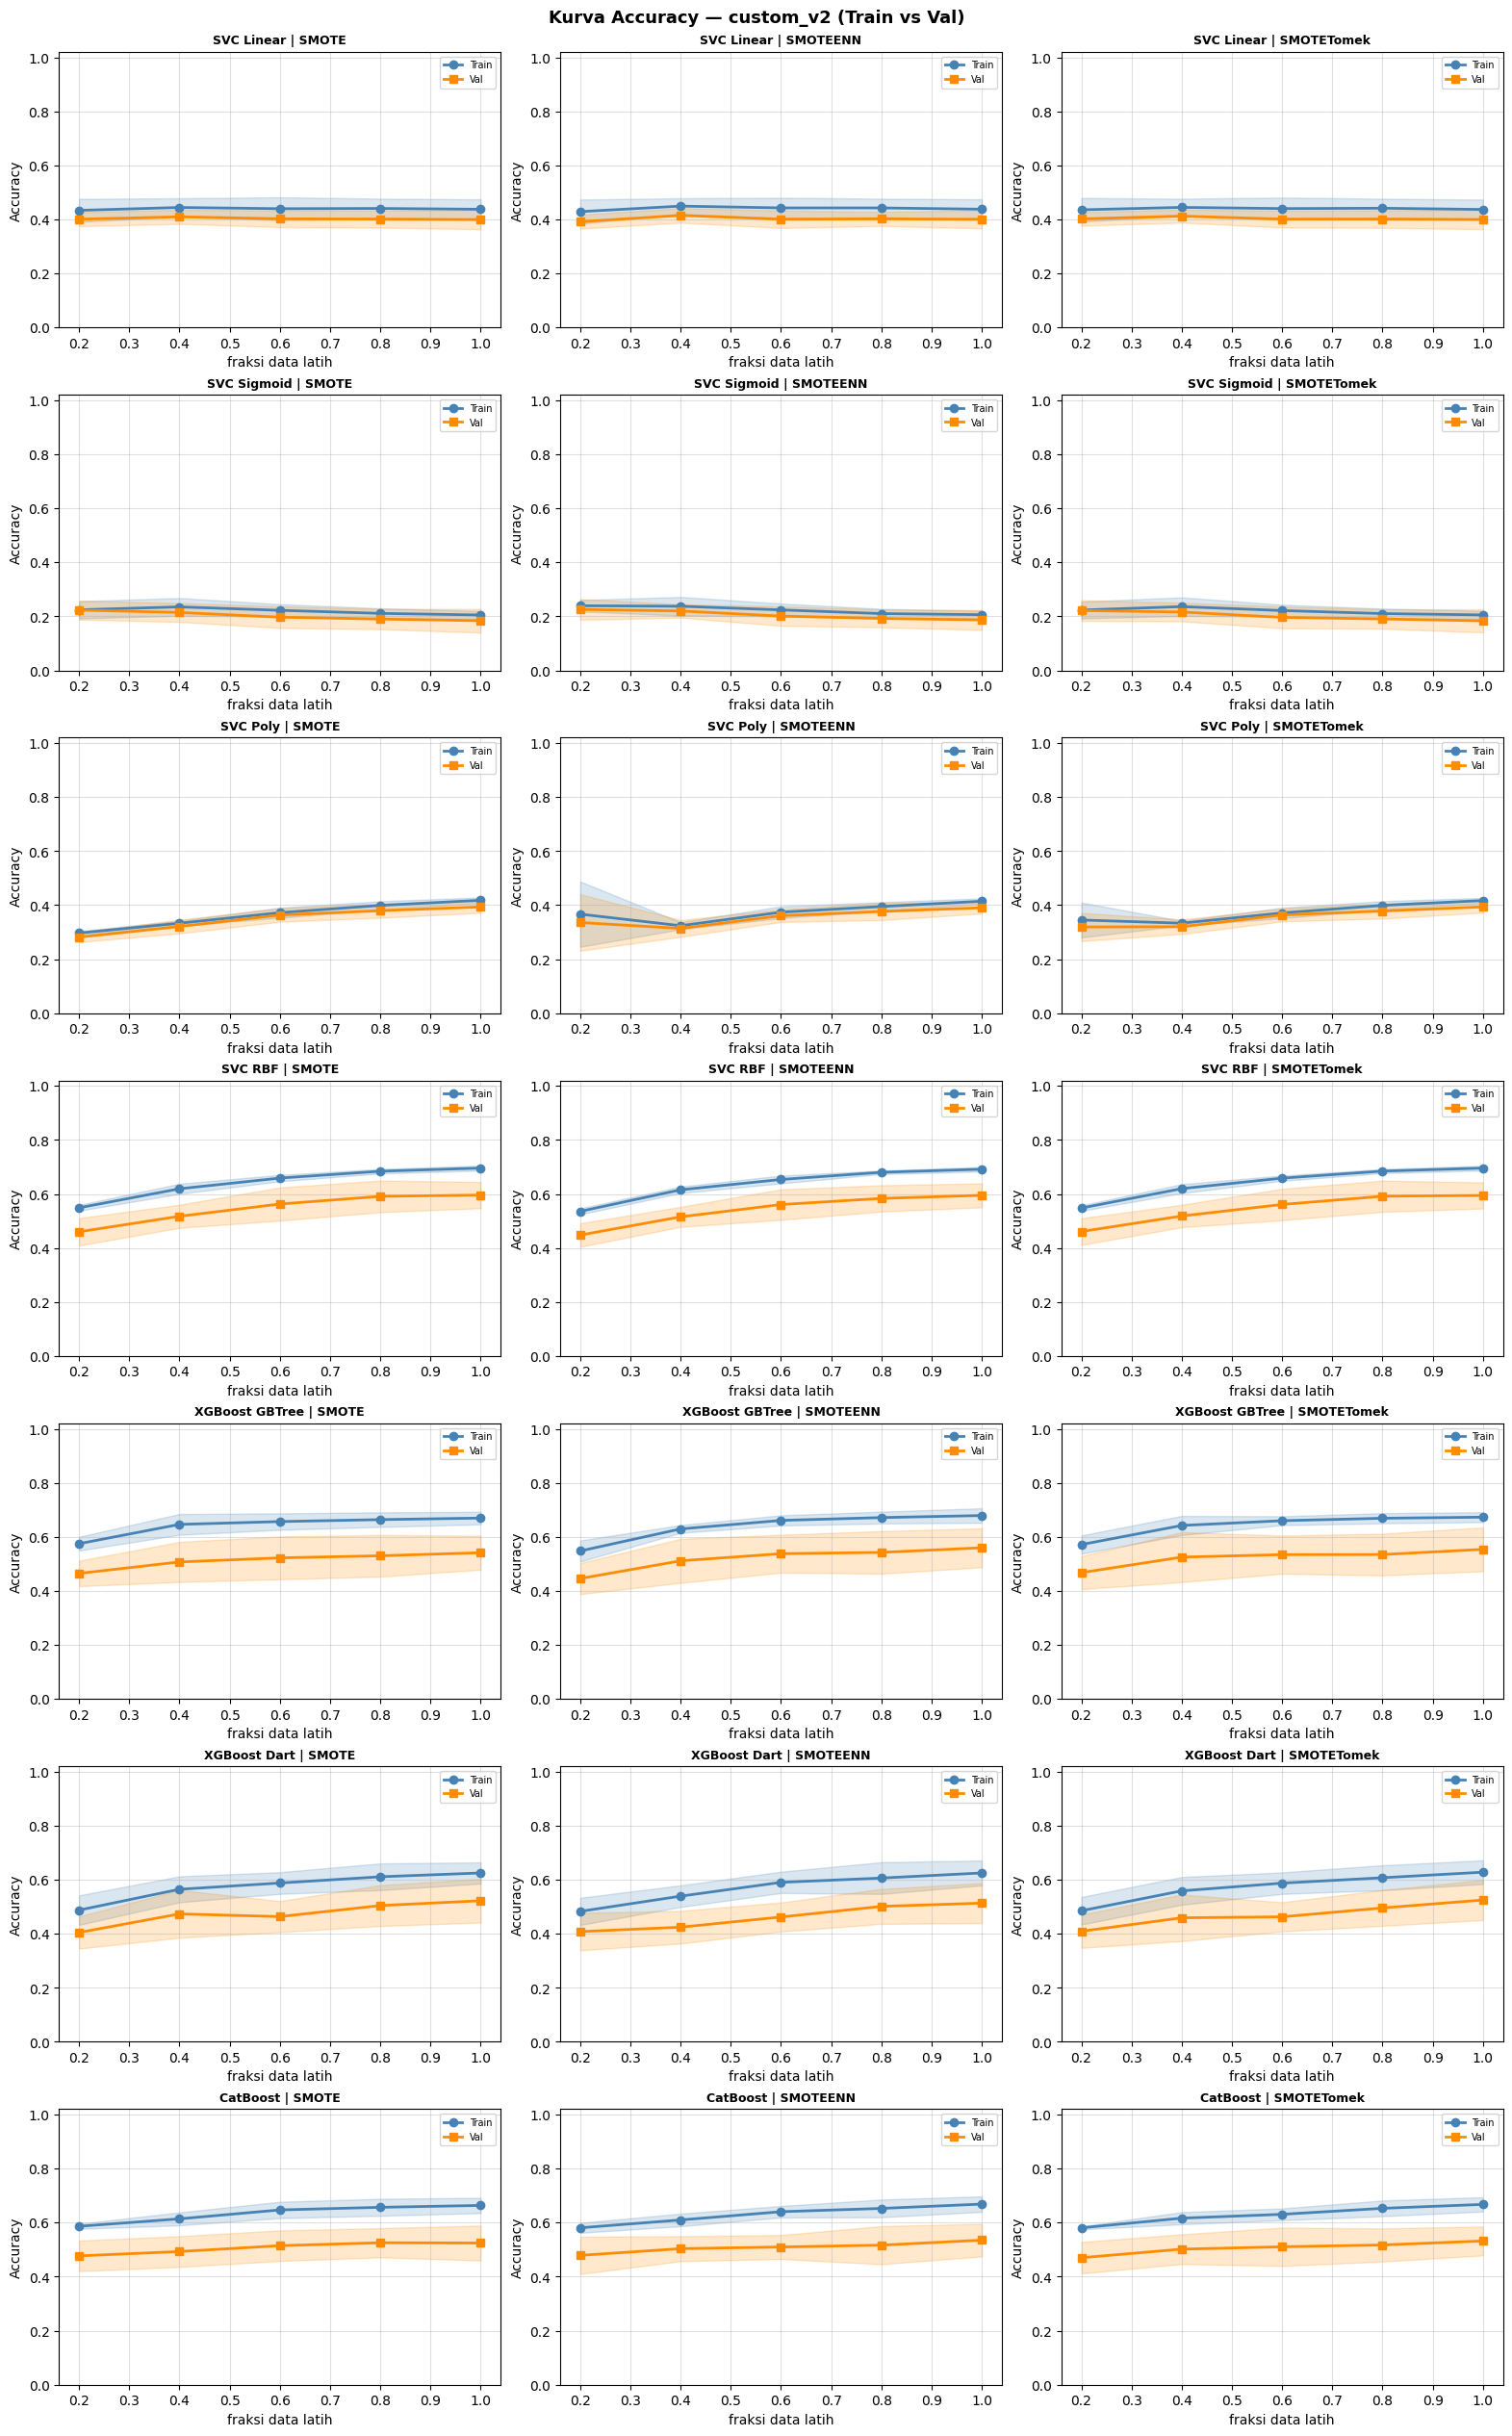

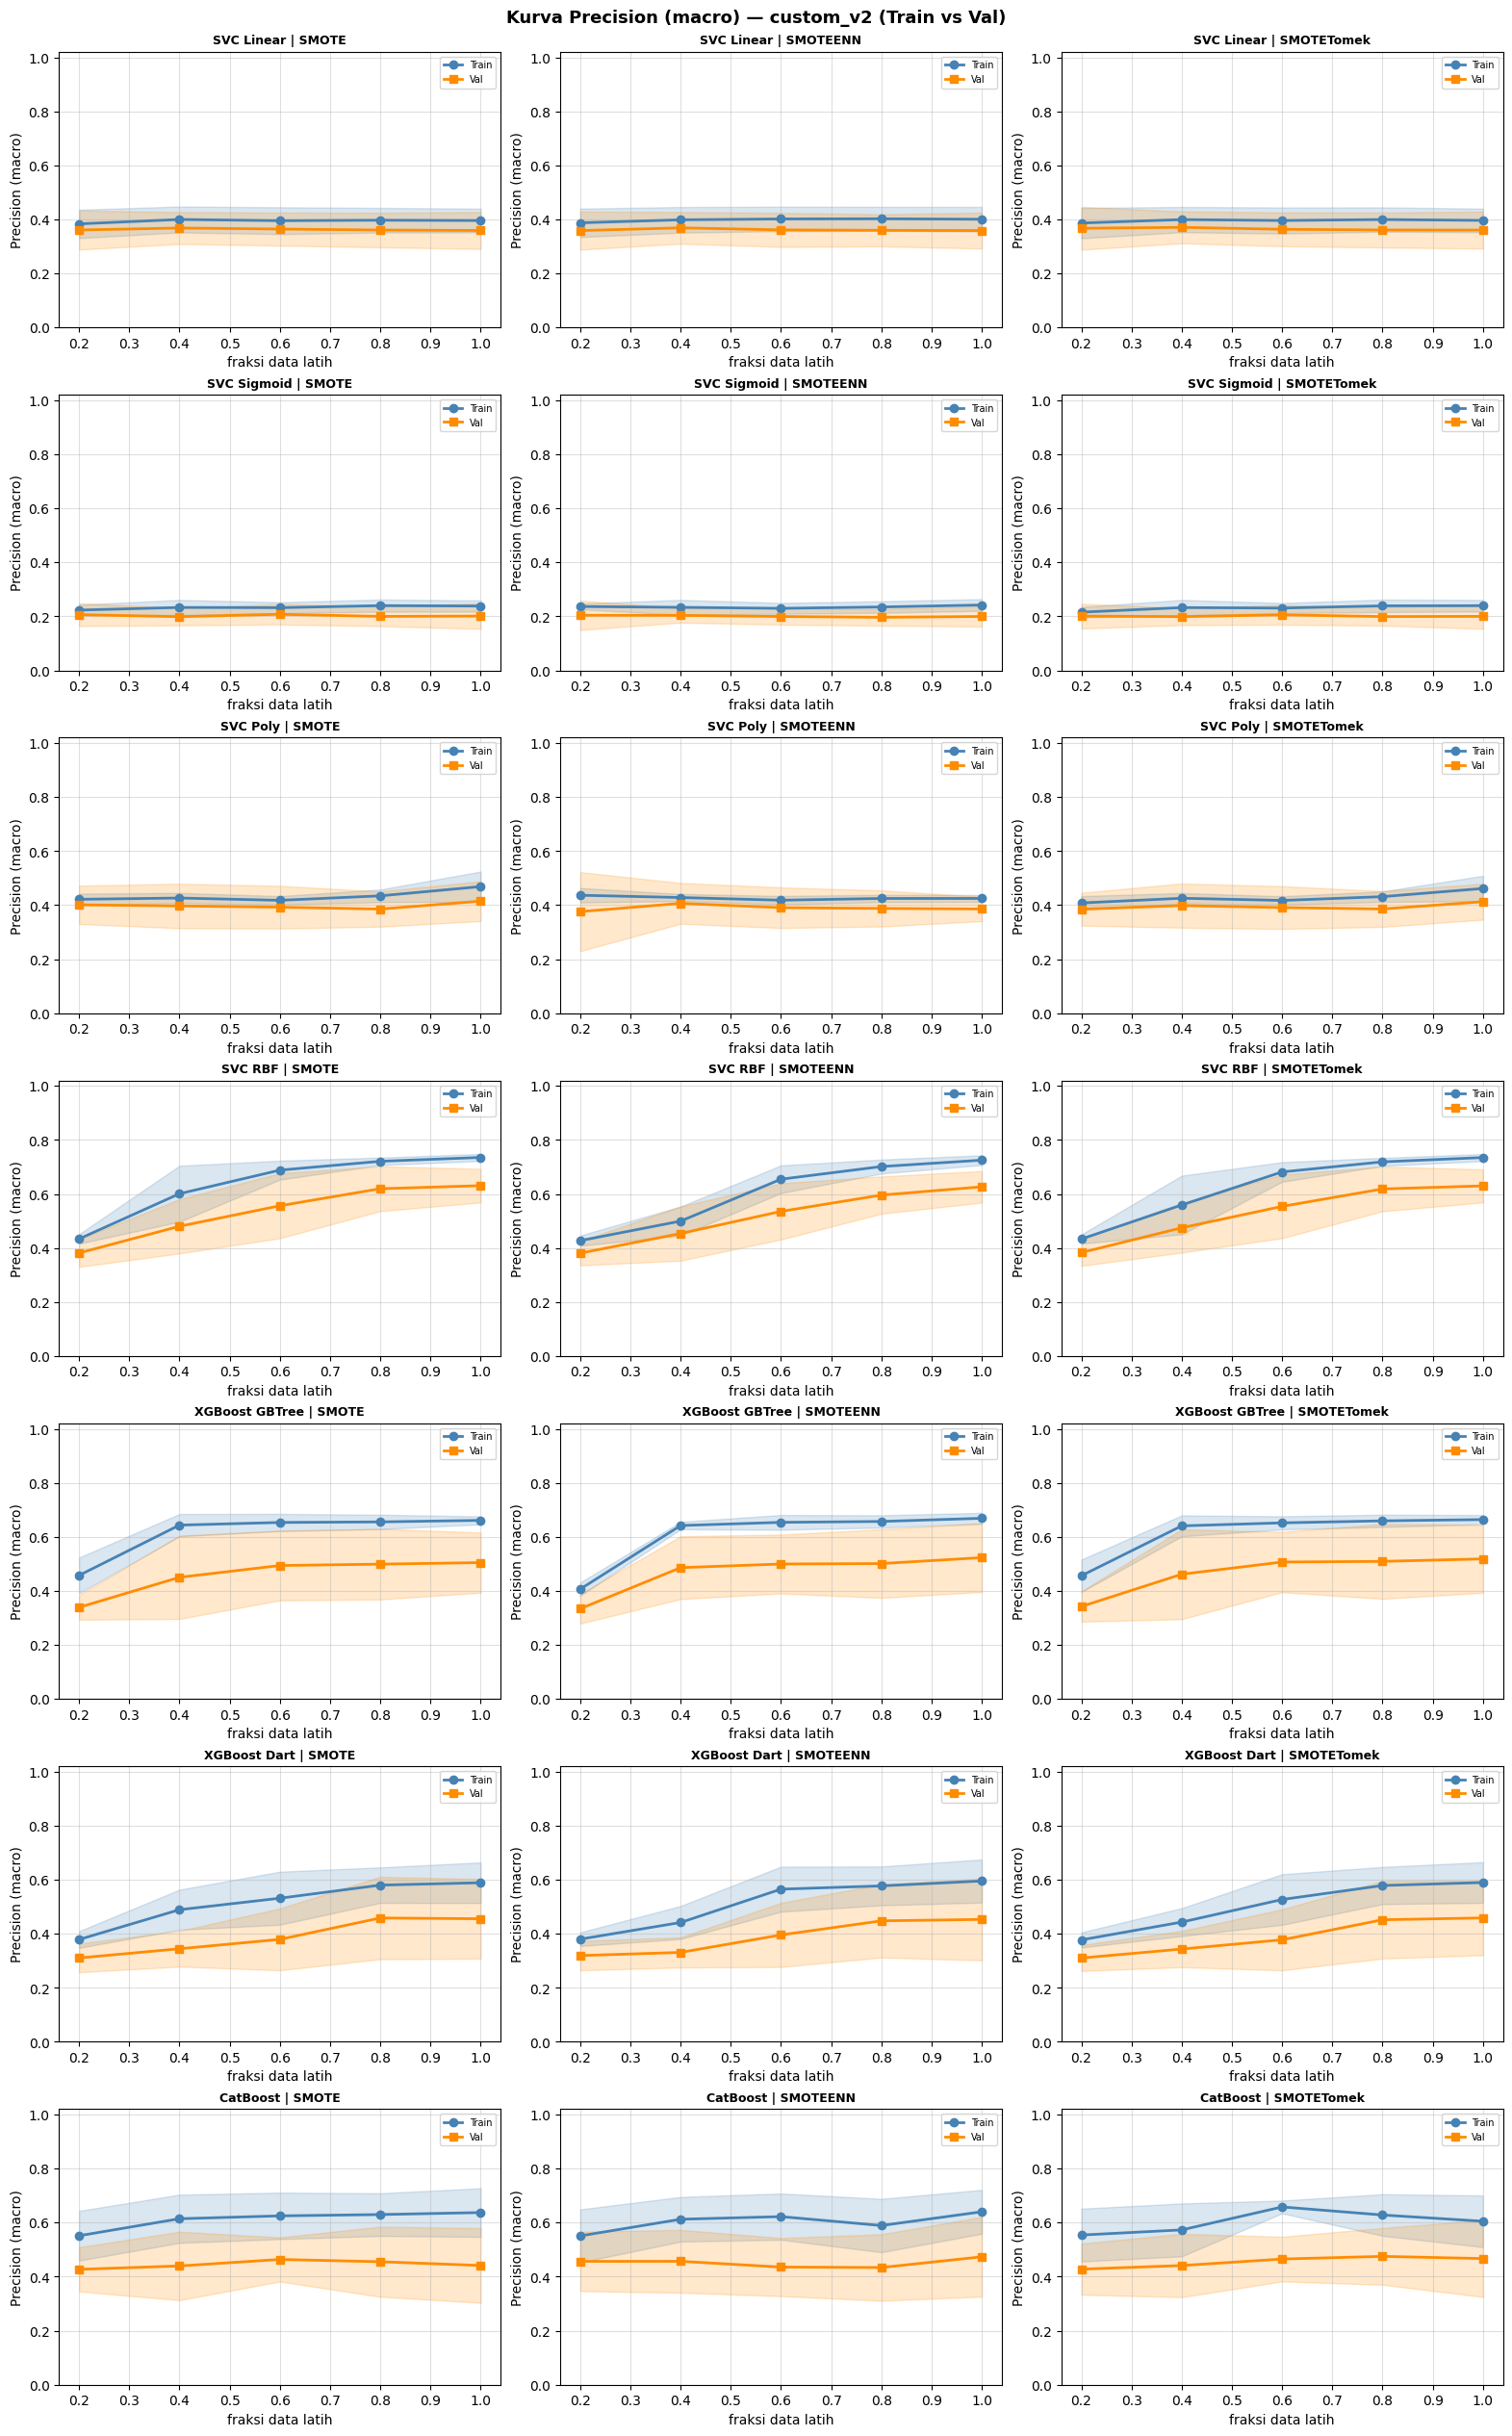

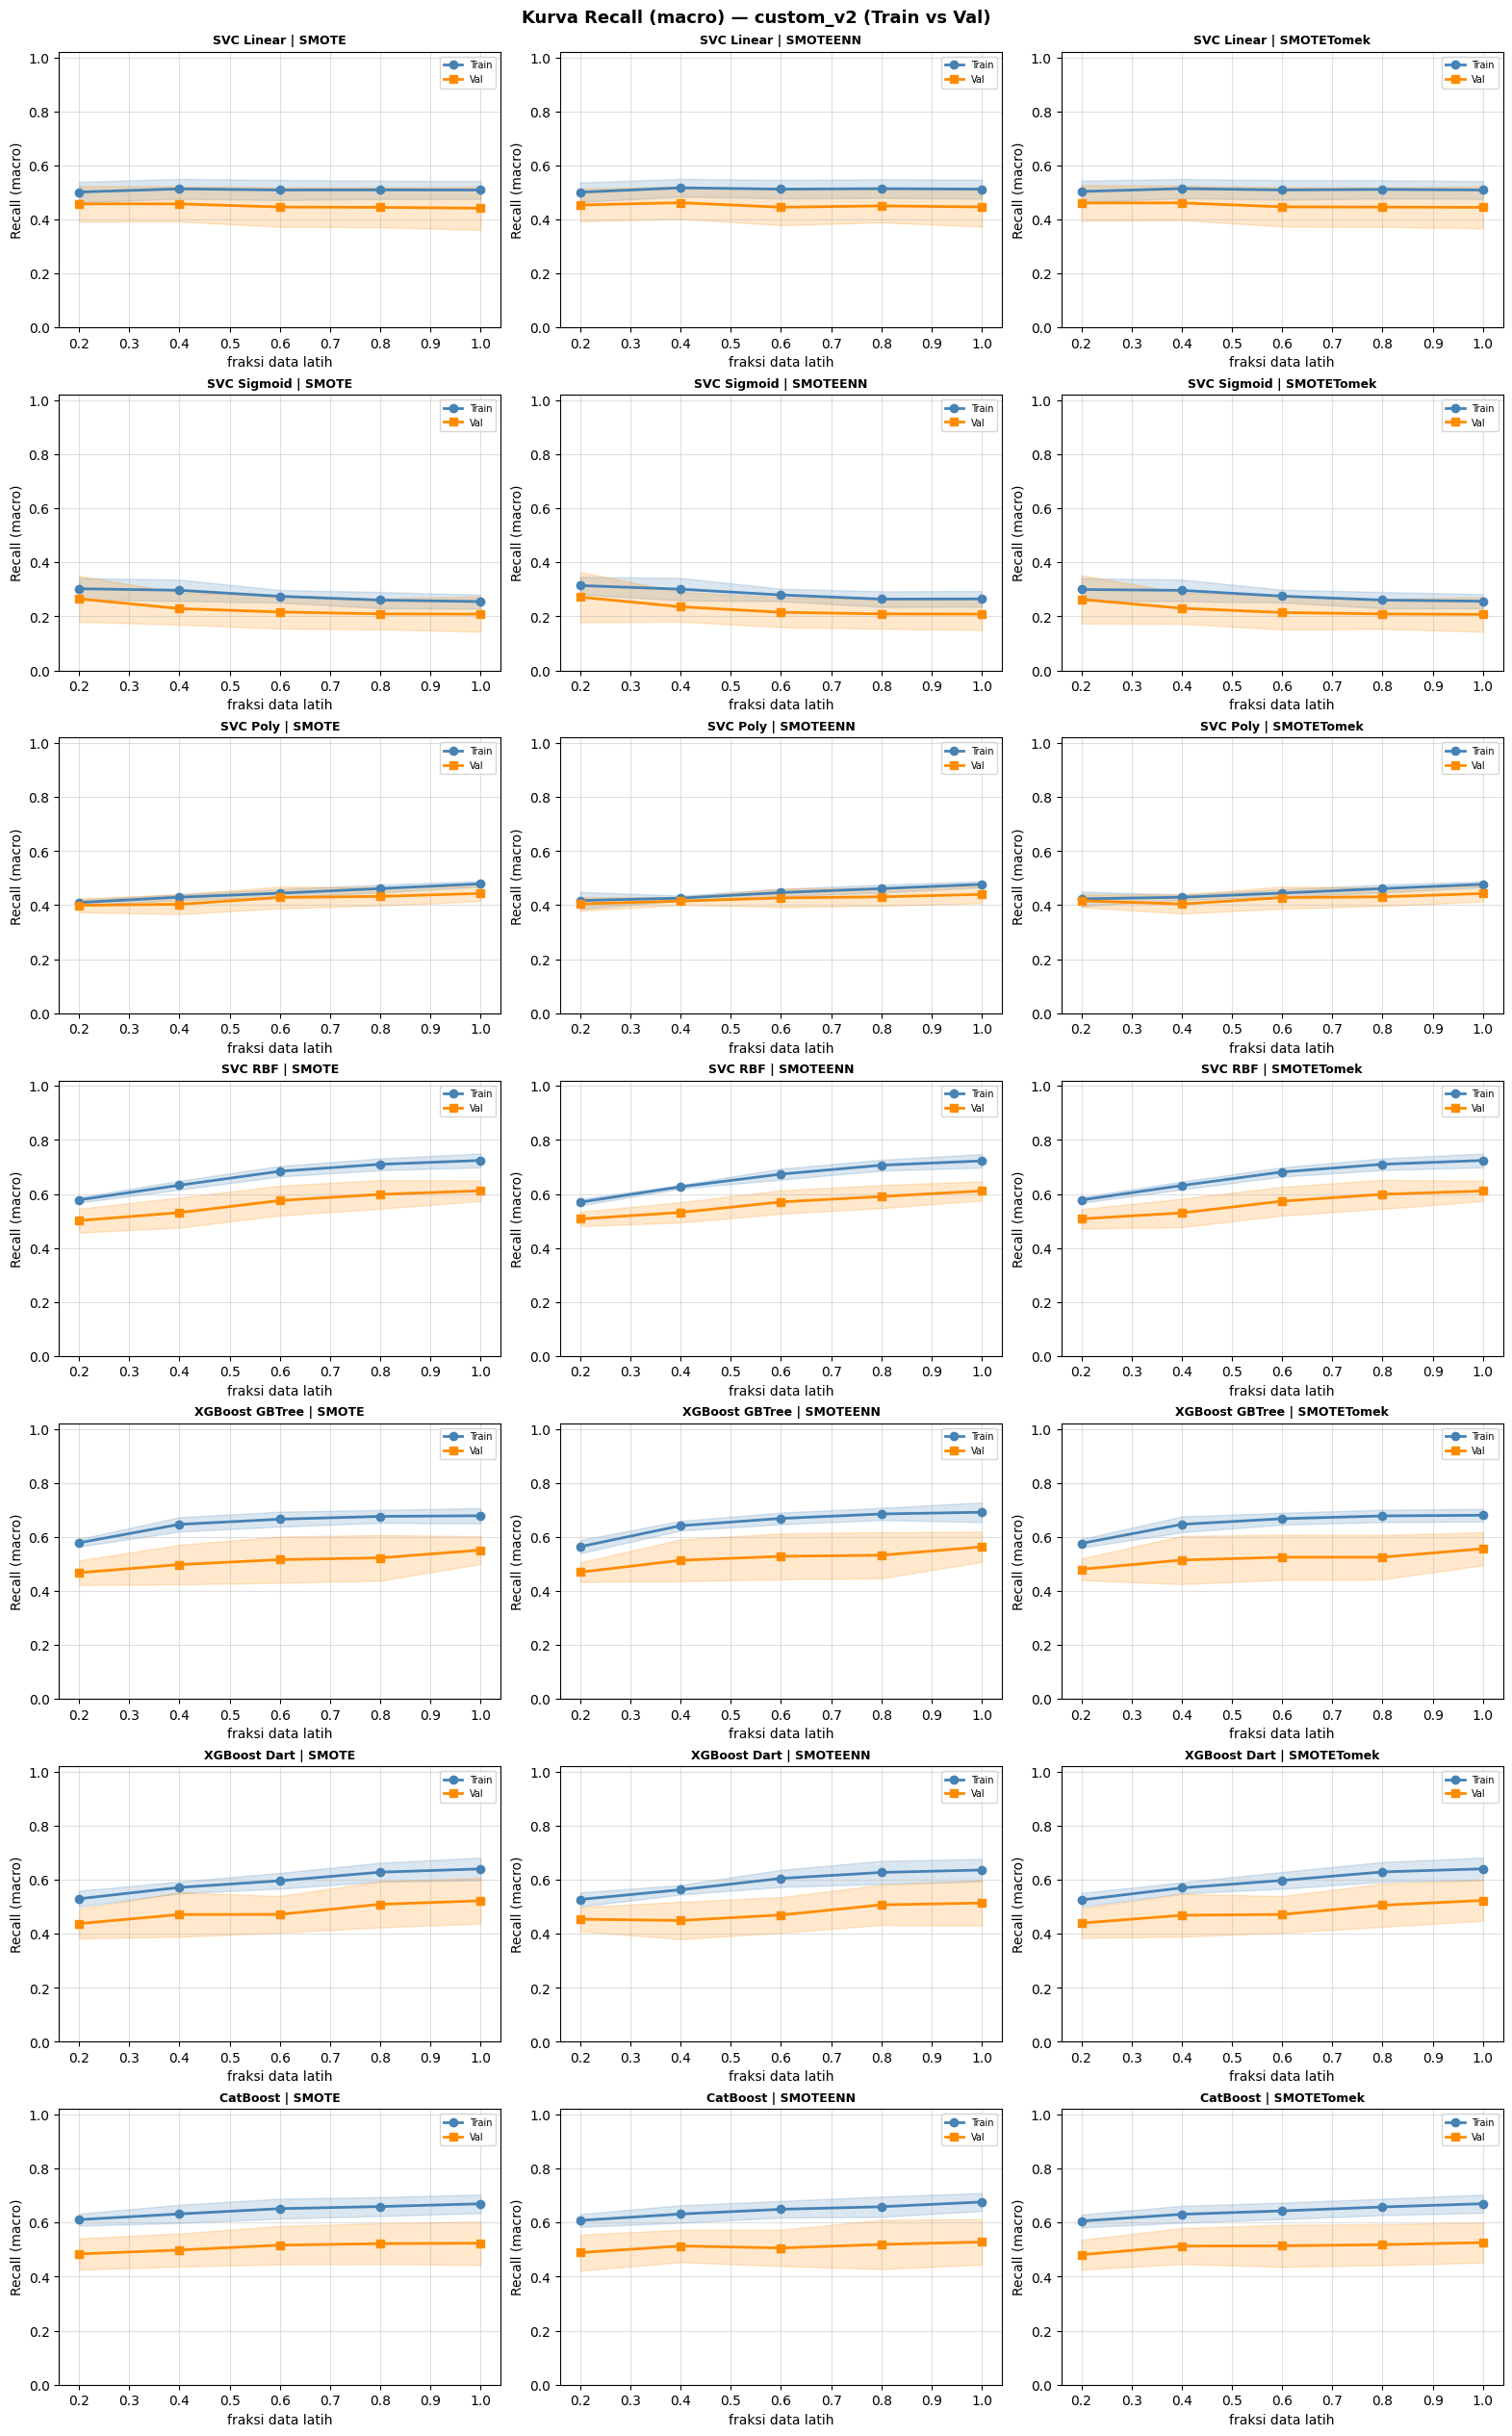

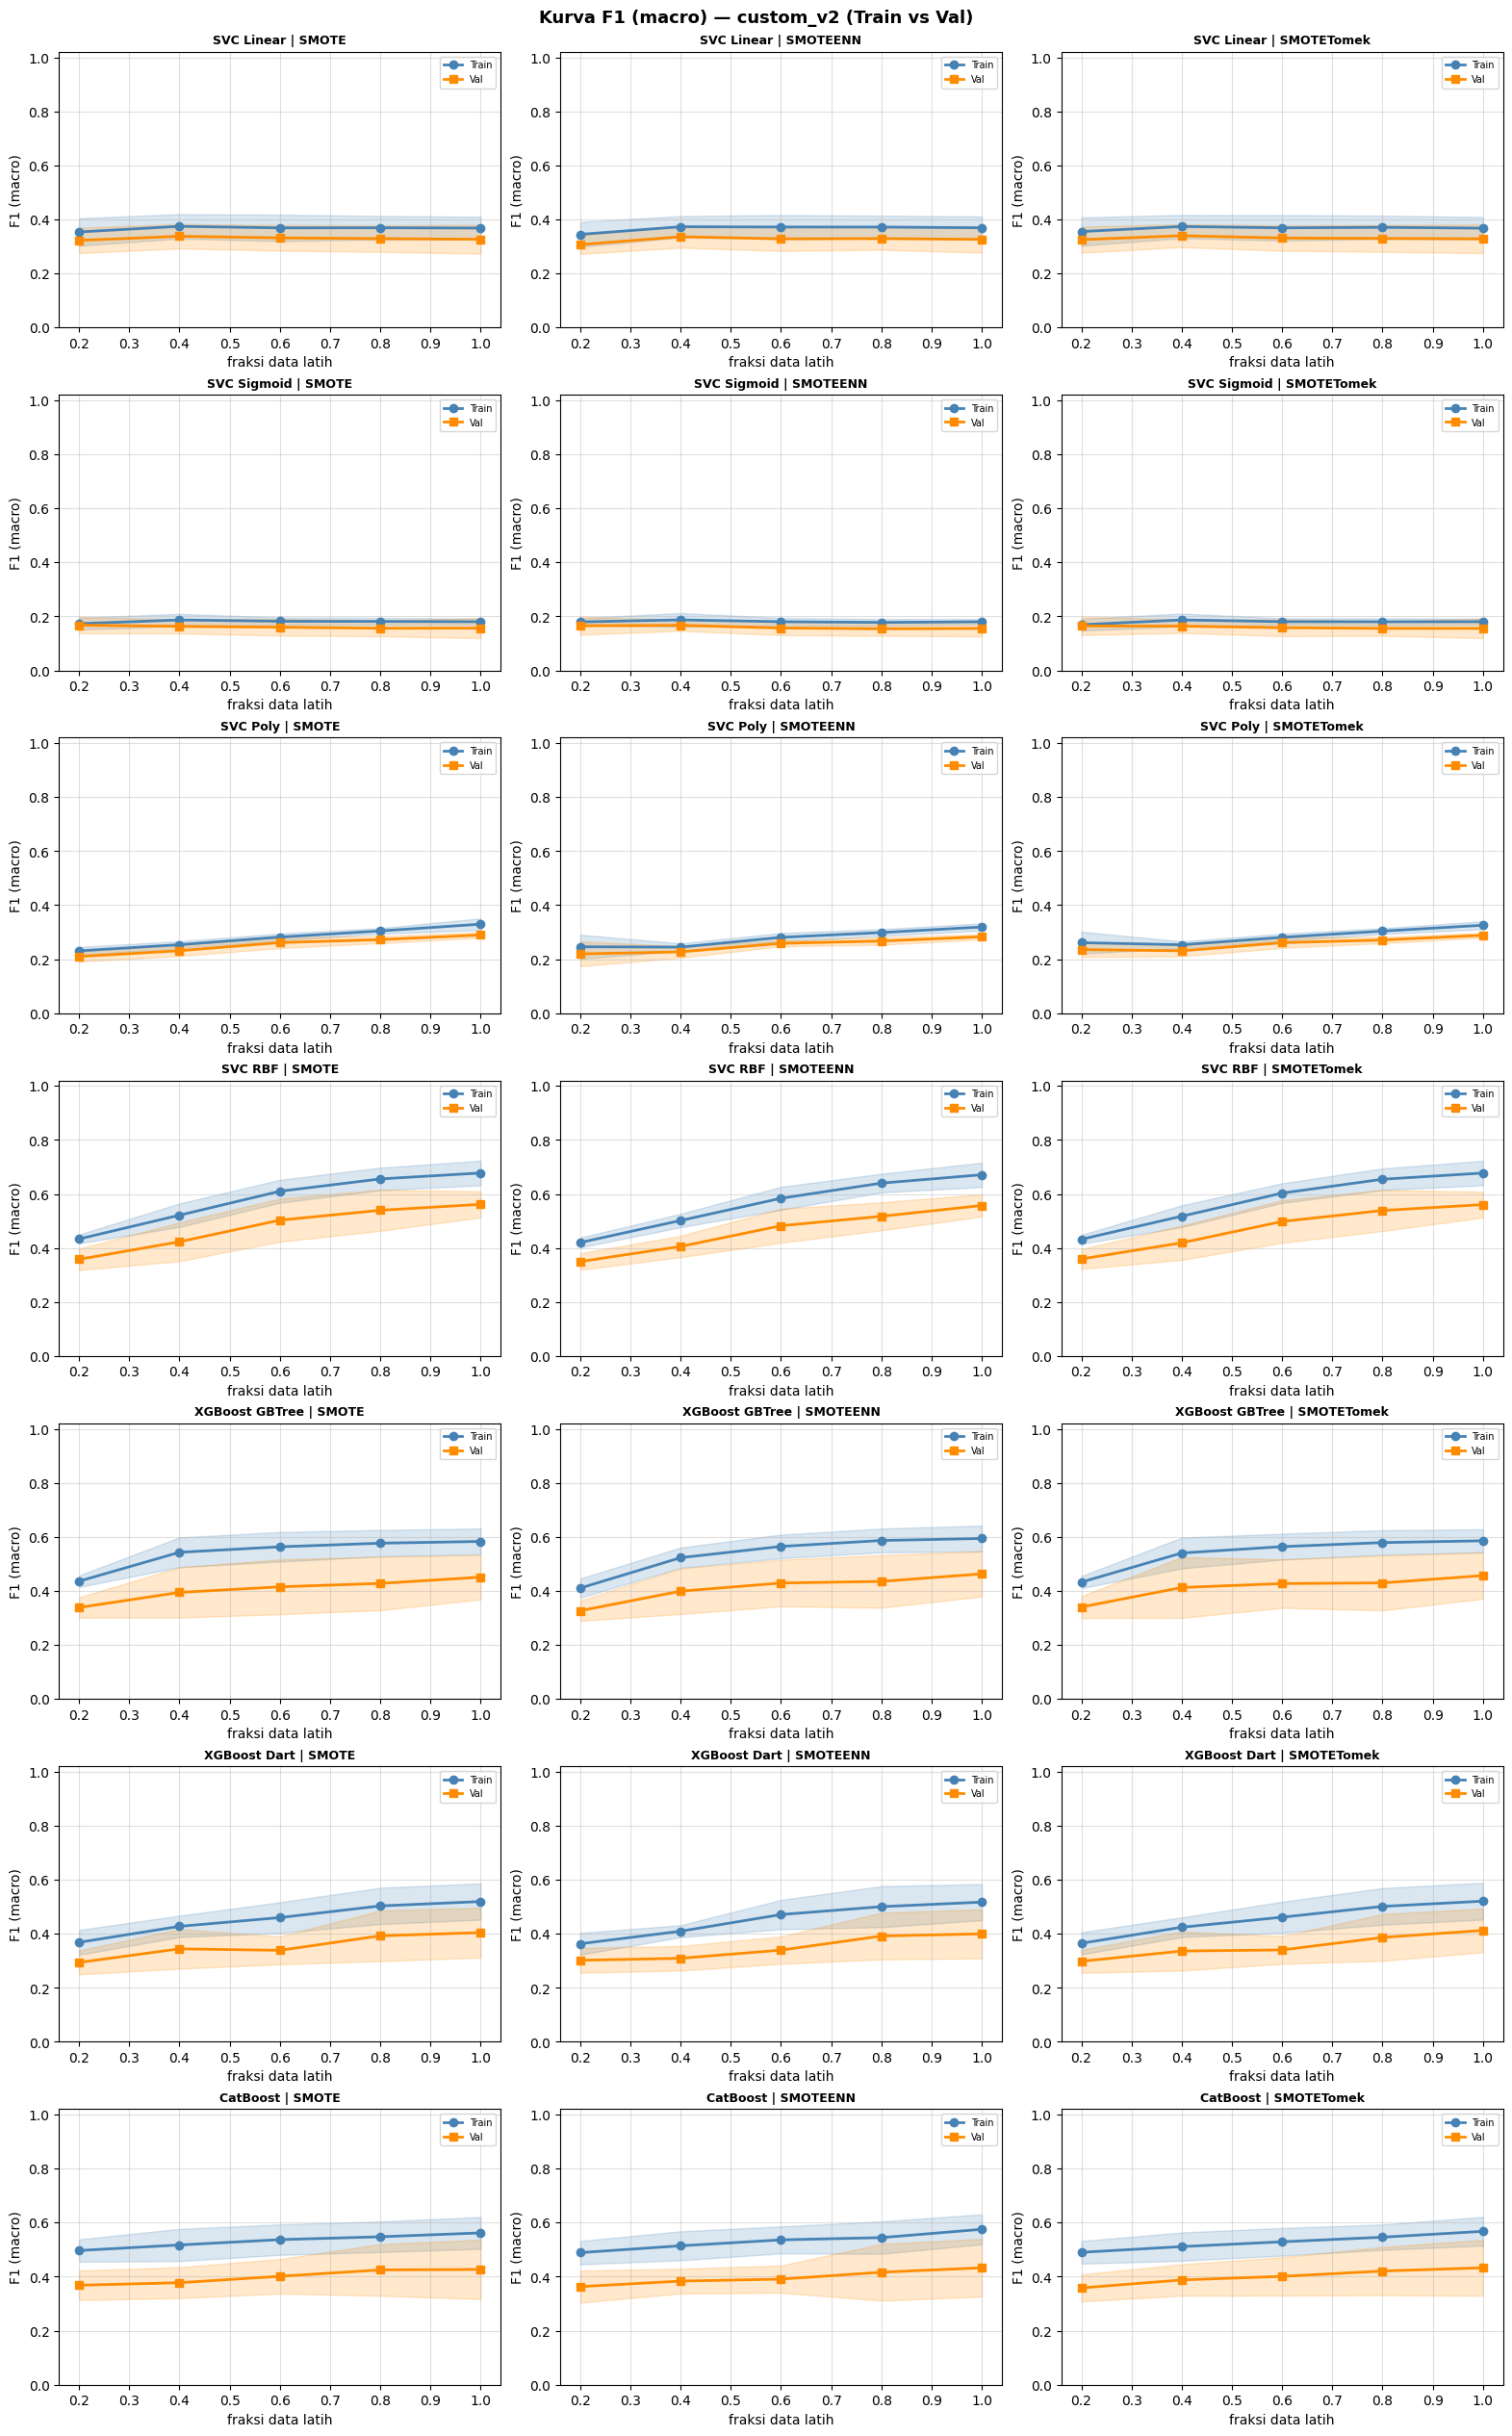

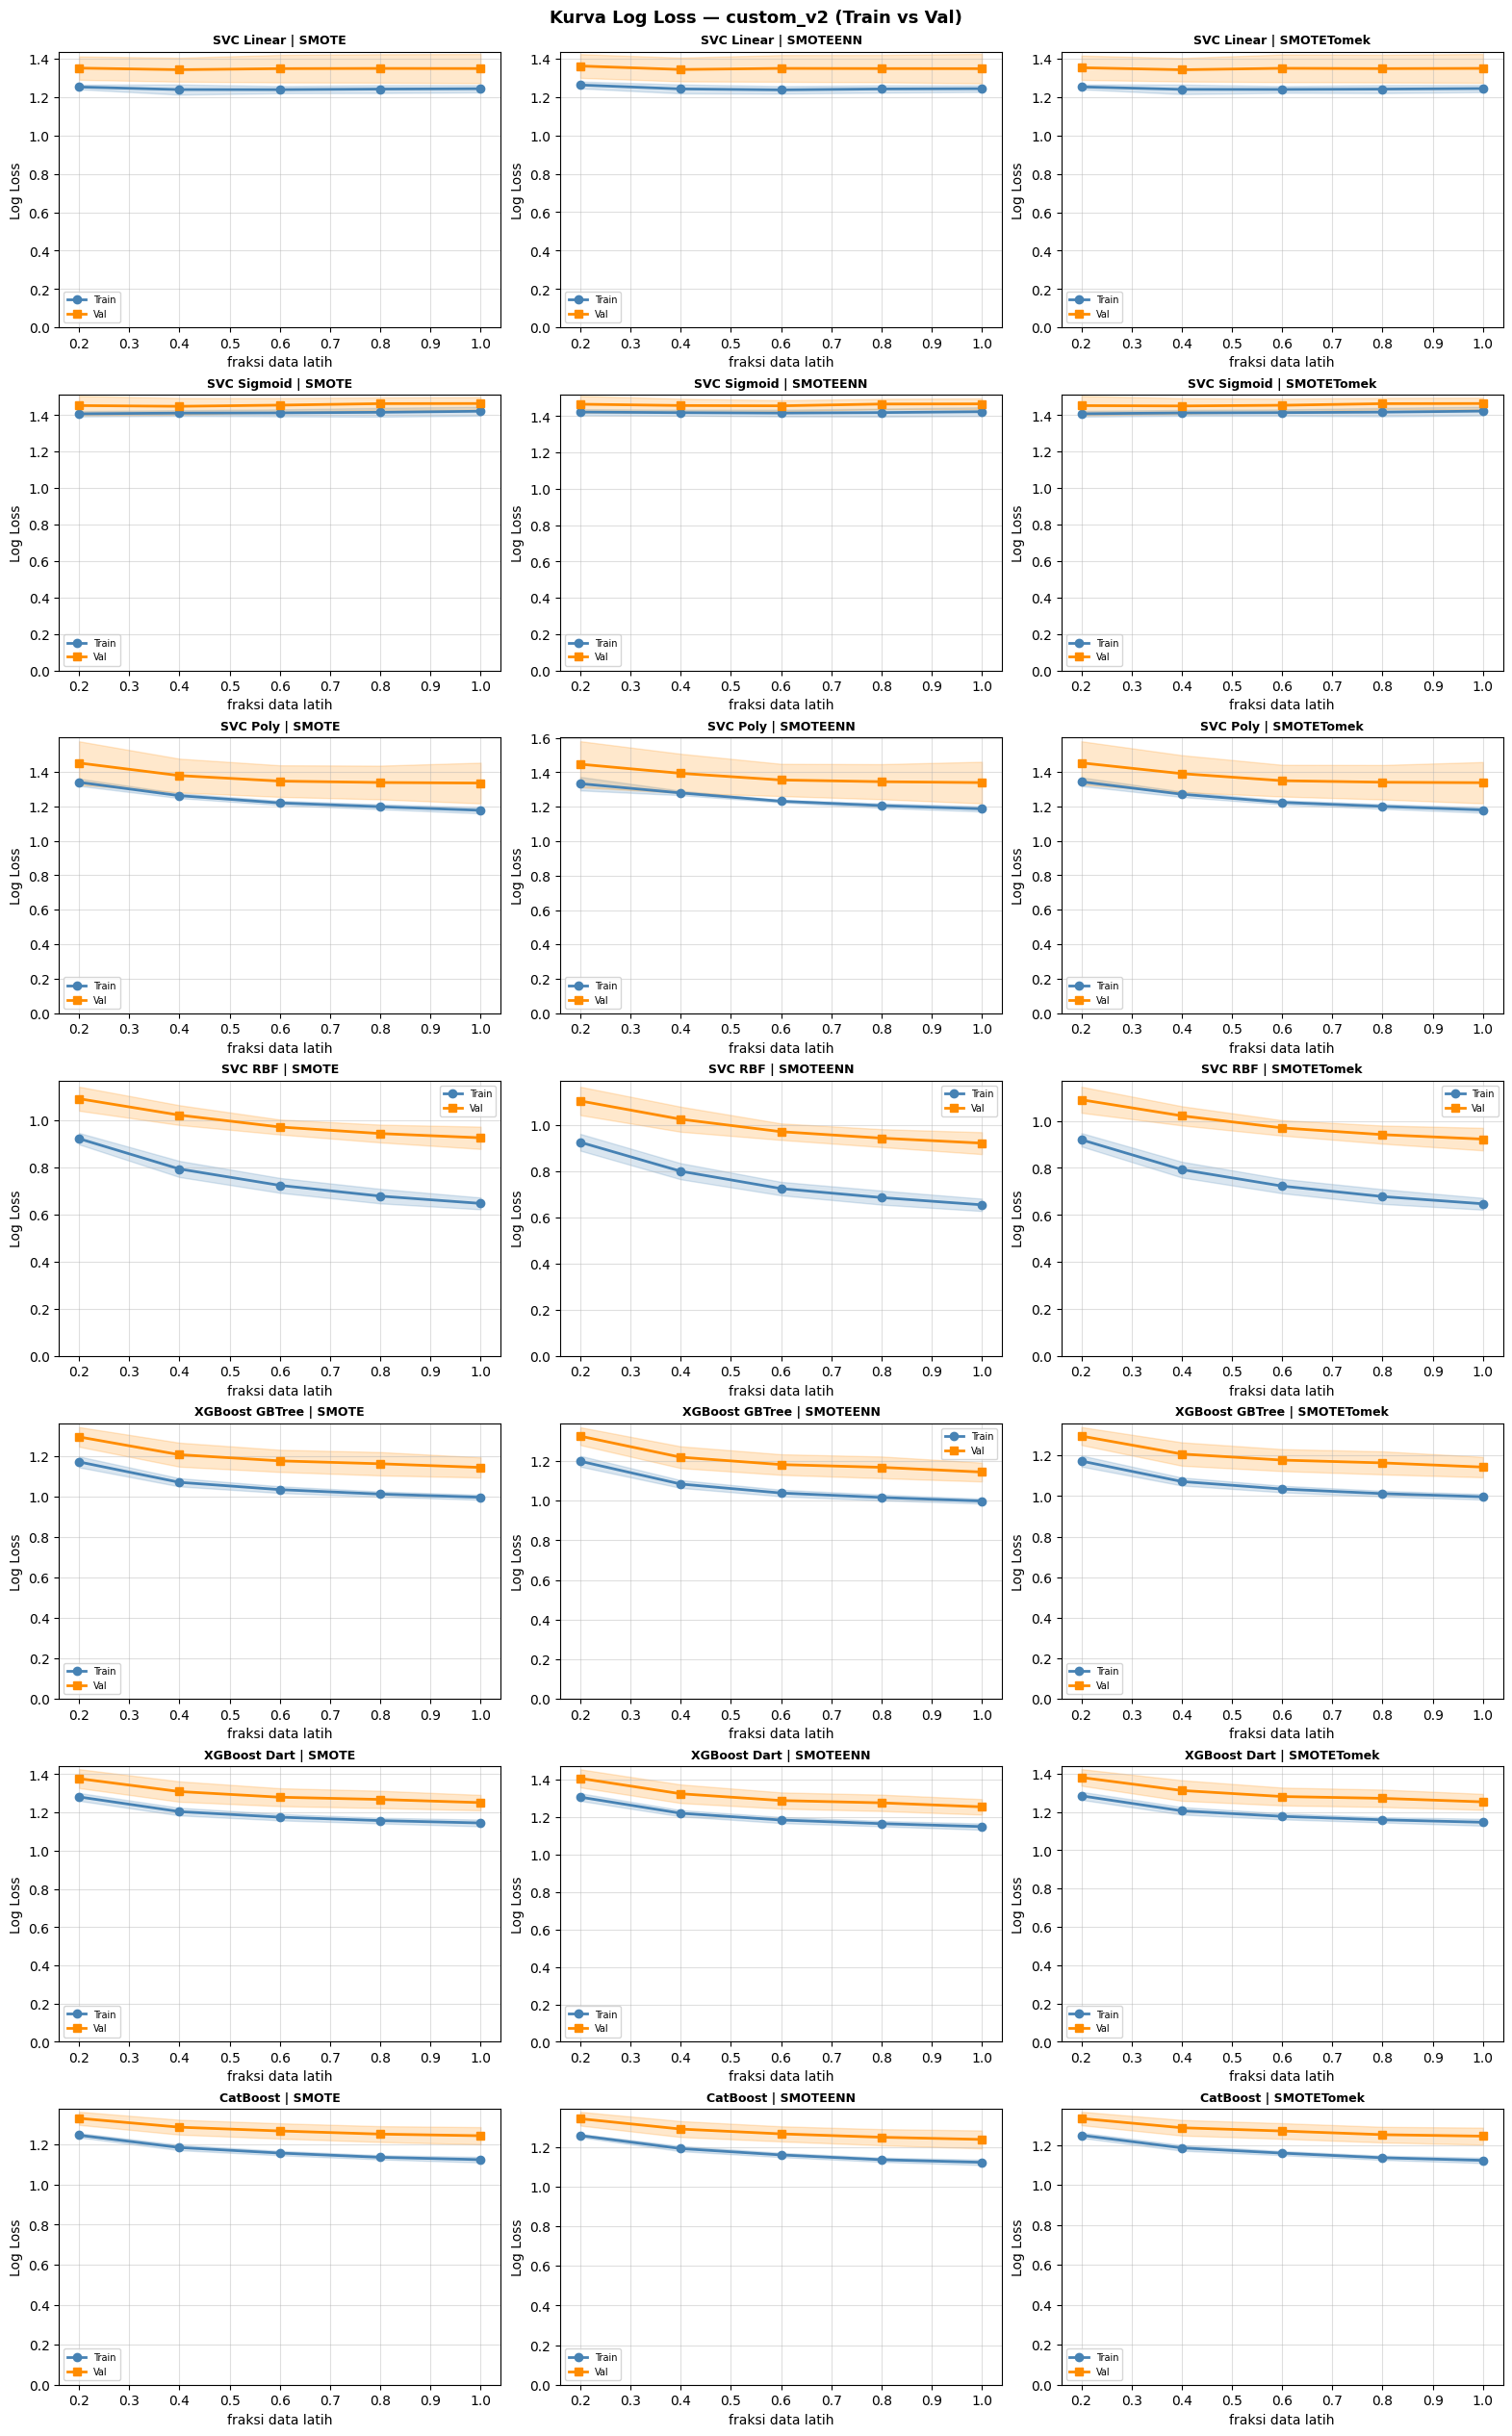

In [32]:
METRIC_TITLES = {'accuracy': 'Accuracy', 'precision_macro': 'Precision (macro)',
                 'recall_macro': 'Recall (macro)', 'f1_macro': 'F1 (macro)',
                 'log_loss': 'Log Loss'}
nrows, ncols = len(MODELS), len(techs)
for metric in CURVE_METRICS:
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.6 * nrows),
                             constrained_layout=True)
    axes = np.atleast_2d(axes)
    for i, name in enumerate(MODELS):
        for j, tech in enumerate(techs):
            ax = axes[i, j]
            if (name, tech) not in curves:
                ax.axis('off'); continue
            ts, trm, trs, vam, vas = curves[(name, tech)][metric]
            ax.plot(ts, trm, 'o-', color='steelblue', lw=2, label='Train')
            ax.fill_between(ts, trm - trs, trm + trs, alpha=0.2, color='steelblue')
            ax.plot(ts, vam, 's-', color='darkorange', lw=2, label='Val')
            ax.fill_between(ts, vam - vas, vam + vas, alpha=0.2, color='darkorange')
            ax.set_title(f'{name} | {tech}', fontsize=9, fontweight='bold')
            ax.set_xlabel('fraksi data latih'); ax.set_ylabel(METRIC_TITLES[metric])
            if metric == 'log_loss':
                ax.set_ylim(bottom=0)
            else:
                ax.set_ylim(0, 1.02)
            ax.grid(True, alpha=0.4); ax.legend(fontsize=7)
    fig.suptitle(f'Kurva {METRIC_TITLES[metric]} — {STRATEGY} (Train vs Val)',
                 fontsize=13, fontweight='bold')
    fig.savefig(os.path.join(OUT_DIR, f'{STRATEGY}_curve_{metric}.png'),
                dpi=110, bbox_inches='tight')
    plt.show()

### Selisih (gap) Train vs Val — tabel terpisah per metrik

Satu tabel untuk tiap metrik (**Accuracy, Precision, Recall, F1**, dan Log Loss), berisi nilai `Train`, `Val`, dan `Selisih (Train-Val)` di fraksi data latih terbesar untuk tiap (model × teknik). Kolom `overfit_gap` menyeragamkan arah: **>0 = indikasi overfit** (skor = Train−Val; `log_loss` = Val−Train, karena loss makin kecil makin baik). Makin besar `overfit_gap`, makin lebar jurang train↔val.

In [35]:
# -- Tabel selisih (gap) Train vs Val, DIPISAH per metrik (fraksi data latih terbesar) --
gap_tables = {}
for metric in CURVE_METRICS:
    rows = []
    for (name, tech), mdict in curves.items():
        ts, trm, trs, vam, vas = mdict[metric]
        train_f, val_f = float(trm[-1]), float(vam[-1])
        train_s, val_s = float(trs[-1]), float(vas[-1])   # std antar-fold di fraksi terbesar
        selisih = train_f - val_f
        overfit_gap = (val_f - train_f) if metric == 'log_loss' else (train_f - val_f)
        rows.append({'Model': name, 'Teknik': tech,
                     'Train': train_f, 'Train_std': train_s,
                     'Val': val_f, 'Val_std': val_s,
                     'Selisih (Train-Val)': selisih, 'overfit_gap': overfit_gap})
    df = pd.DataFrame(rows)
    gap_tables[metric] = df
    df.to_csv(os.path.join(OUT_DIR, f'{STRATEGY}_gap_{metric}.csv'), index=False)
    log(f'[{METRIC_TITLES[metric]}] selisih train-val -> {STRATEGY}_gap_{metric}.csv')

# Tampilkan satu tabel per metrik: Train & Val sbg 'mean ± std' (overfit_gap diwarnai).
for metric in CURVE_METRICS:
    df = gap_tables[metric]
    disp = pd.DataFrame({'Model': df['Model'], 'Teknik': df['Teknik']})
    disp['Train'] = [f'{m:.4f} ± {s:.4f}' for m, s in zip(df['Train'], df['Train_std'])]
    disp['Val']   = [f'{m:.4f} ± {s:.4f}' for m, s in zip(df['Val'], df['Val_std'])]
    disp['Selisih (Train-Val)'] = df['Selisih (Train-Val)']
    disp['overfit_gap'] = df['overfit_gap']
    print('=' * 60)
    print(f'Metrik: {METRIC_TITLES[metric]}')
    display(disp.style.format({'Selisih (Train-Val)': '{:.4f}', 'overfit_gap': '{:.4f}'})
            .background_gradient(cmap='Reds', subset=['overfit_gap']))

[Accuracy] selisih train-val -> custom_v2_gap_accuracy.csv
[Precision (macro)] selisih train-val -> custom_v2_gap_precision_macro.csv
[Recall (macro)] selisih train-val -> custom_v2_gap_recall_macro.csv
[F1 (macro)] selisih train-val -> custom_v2_gap_f1_macro.csv
[Log Loss] selisih train-val -> custom_v2_gap_log_loss.csv
Metrik: Accuracy


,Model,Teknik,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,SMOTE,0.4378 ± 0.0369,0.3995 ± 0.0357,0.0383,0.0383
1,SVC Linear,SMOTEENN,0.4380 ± 0.0367,0.4005 ± 0.0334,0.0375,0.0375
2,SVC Linear,SMOTETomek,0.4371 ± 0.0365,0.3998 ± 0.0360,0.0373,0.0373
3,SVC Sigmoid,SMOTE,0.2051 ± 0.0147,0.1839 ± 0.0438,0.0212,0.0212
4,SVC Sigmoid,SMOTEENN,0.2063 ± 0.0142,0.1867 ± 0.0369,0.0196,0.0196
5,SVC Sigmoid,SMOTETomek,0.2054 ± 0.0148,0.1834 ± 0.0428,0.0219,0.0219
6,SVC Poly,SMOTE,0.4183 ± 0.0107,0.3937 ± 0.0218,0.0246,0.0246
7,SVC Poly,SMOTEENN,0.4147 ± 0.0105,0.3907 ± 0.0215,0.0241,0.0241
8,SVC Poly,SMOTETomek,0.4173 ± 0.0101,0.3939 ± 0.0214,0.0234,0.0234
9,SVC RBF,SMOTE,0.6961 ± 0.0092,0.5962 ± 0.0486,0.0999,0.0999


Metrik: Precision (macro)


,Model,Teknik,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,SMOTE,0.3961 ± 0.0441,0.3592 ± 0.0684,0.0369,0.0369
1,SVC Linear,SMOTEENN,0.4008 ± 0.0457,0.3589 ± 0.0666,0.0419,0.0419
2,SVC Linear,SMOTETomek,0.3965 ± 0.0436,0.3607 ± 0.0686,0.0358,0.0358
3,SVC Sigmoid,SMOTE,0.2382 ± 0.0208,0.2011 ± 0.0475,0.0371,0.0371
4,SVC Sigmoid,SMOTEENN,0.2420 ± 0.0217,0.1996 ± 0.0376,0.0424,0.0424
5,SVC Sigmoid,SMOTETomek,0.2395 ± 0.0214,0.2000 ± 0.0460,0.0395,0.0395
6,SVC Poly,SMOTE,0.4689 ± 0.0557,0.4150 ± 0.0737,0.0539,0.0539
7,SVC Poly,SMOTEENN,0.4250 ± 0.0128,0.3860 ± 0.0452,0.0390,0.0390
8,SVC Poly,SMOTETomek,0.4619 ± 0.0470,0.4129 ± 0.0665,0.0490,0.0490
9,SVC RBF,SMOTE,0.7355 ± 0.0130,0.6310 ± 0.0622,0.1044,0.1044


Metrik: Recall (macro)


,Model,Teknik,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,SMOTE,0.5091 ± 0.0332,0.4416 ± 0.0803,0.0675,0.0675
1,SVC Linear,SMOTEENN,0.5123 ± 0.0353,0.4464 ± 0.0729,0.0659,0.0659
2,SVC Linear,SMOTETomek,0.5092 ± 0.0329,0.4448 ± 0.0777,0.0644,0.0644
3,SVC Sigmoid,SMOTE,0.2548 ± 0.0256,0.2084 ± 0.0651,0.0464,0.0464
4,SVC Sigmoid,SMOTEENN,0.2646 ± 0.0293,0.2086 ± 0.0590,0.0560,0.0560
5,SVC Sigmoid,SMOTETomek,0.2561 ± 0.0264,0.2072 ± 0.0641,0.0489,0.0489
6,SVC Poly,SMOTE,0.4792 ± 0.0105,0.4435 ± 0.0281,0.0357,0.0357
7,SVC Poly,SMOTEENN,0.4774 ± 0.0117,0.4401 ± 0.0322,0.0373,0.0373
8,SVC Poly,SMOTETomek,0.4775 ± 0.0107,0.4431 ± 0.0293,0.0344,0.0344
9,SVC RBF,SMOTE,0.7244 ± 0.0258,0.6121 ± 0.0381,0.1123,0.1123


Metrik: F1 (macro)


,Model,Teknik,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,SMOTE,0.3682 ± 0.0421,0.3267 ± 0.0535,0.0415,0.0415
1,SVC Linear,SMOTEENN,0.3692 ± 0.0422,0.3264 ± 0.0492,0.0428,0.0428
2,SVC Linear,SMOTETomek,0.3677 ± 0.0415,0.3283 ± 0.0531,0.0394,0.0394
3,SVC Sigmoid,SMOTE,0.1801 ± 0.0117,0.1564 ± 0.0371,0.0237,0.0237
4,SVC Sigmoid,SMOTEENN,0.1799 ± 0.0103,0.1554 ± 0.0293,0.0245,0.0245
5,SVC Sigmoid,SMOTETomek,0.1803 ± 0.0118,0.1553 ± 0.0359,0.0249,0.0249
6,SVC Poly,SMOTE,0.3298 ± 0.0216,0.2899 ± 0.0103,0.0400,0.0400
7,SVC Poly,SMOTEENN,0.3193 ± 0.0136,0.2831 ± 0.0096,0.0362,0.0362
8,SVC Poly,SMOTETomek,0.3259 ± 0.0147,0.2887 ± 0.0089,0.0371,0.0371
9,SVC RBF,SMOTE,0.6779 ± 0.0457,0.5618 ± 0.0484,0.1161,0.1161


Metrik: Log Loss


,Model,Teknik,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,SMOTE,1.2437 ± 0.0189,1.3488 ± 0.0757,-0.1051,0.1051
1,SVC Linear,SMOTEENN,1.2427 ± 0.0171,1.3469 ± 0.0765,-0.1041,0.1041
2,SVC Linear,SMOTETomek,1.2438 ± 0.0186,1.3486 ± 0.0750,-0.1048,0.1048
3,SVC Sigmoid,SMOTE,1.4220 ± 0.0245,1.4643 ± 0.0355,-0.0423,0.0423
4,SVC Sigmoid,SMOTEENN,1.4249 ± 0.0239,1.4679 ± 0.0301,-0.0430,0.0430
5,SVC Sigmoid,SMOTETomek,1.4228 ± 0.0239,1.4643 ± 0.0321,-0.0415,0.0415
6,SVC Poly,SMOTE,1.1768 ± 0.0176,1.3350 ± 0.1181,-0.1582,0.1582
7,SVC Poly,SMOTEENN,1.1880 ± 0.0155,1.3404 ± 0.1210,-0.1525,0.1525
8,SVC Poly,SMOTETomek,1.1788 ± 0.0163,1.3367 ± 0.1197,-0.1580,0.1580
9,SVC RBF,SMOTE,0.6474 ± 0.0250,0.9257 ± 0.0473,-0.2782,0.2782


## 11. Kesimpulan

- **Tabel best-per-model (sel 6)**: teknik (atau adjusted) mana yang menang di tiap model, pada `CUSTOM_TARGETS` yang dipilih.
- Bandingkan SMOTE vs SMOTEENN vs SMOTETomek vs adjusted di bar chart & confusion matrix (recall kelas **B**).
- **Bisa diatur**: ubah `CUSTOM_TARGETS` di sel Konfigurasi (mis. `{'B': 'C', 'E': 'C'}`, angka absolut, atau samakan ke kelas lain) lalu jalankan ulang — semua teknik mengikuti.
- Catatan teknik: `smote` mencapai target eksak tanpa menyentuh kelas lain; `smoteenn`/`smotetomek` menaikkan kelas minoritas lalu memangkas batas semua kelas (ENN lebih agresif). Borderline-SMOTE sengaja tak dipakai di sini karena tak menambah kelas yang sudah terpisah rapi (mis. B).
- Learning curve (sel 9): cek apakah resampling bikin overfit (gap besar).
- CV memakai `StratifiedGroupKFold` dengan grup `Sampling_ID`; resampling hanya di fold training (tak bocor ke validasi). Grup `Sampling_ID` dijaga, sehingga replika dari sampel yang sama tak tersebar ke train + validasi (anti kebocoran ber-grup).

File hasil di `OUT_DIR`.
